# Digital signal processing. Lab5

In [14]:
f_1 = 50.0
f_2 = 150.0
f_3 = 450.0

Fs = 2000 
dt_1 = 1.0 / Fs

w_1 = 2 * np.pi * f_1
w_2 = 2 * np.pi * f_2
w_3 = 2 * np.pi * f_3

signal_1 = lambda t : np.cos(w_1 * t) + np.cos(w_2 * t) + np.cos(w_3 * t)

## Task1

- Реализовать вейвлет Морле во временном пространстве $\psi(t)$, формула (1).
- Реализовать вейвлет Морле в частотном пространстве $\psi(\omega)$. Это можно сделать используя обратное преобразование Фурье от $\psi(t)$ или воспользоваться формулой (2).

$$\psi(t) = e^{-\frac{t^2}{\alpha^2}} e^{i\omega_0 t} \quad (1)$$

$$\hat{\psi}(\omega) = \alpha\sqrt{\pi} e^{-\alpha^2 \frac{(\omega - \omega_0)^2}{4}} \quad (2)$$

Используя формулу вейвлета Морле, выясните, как сместить основную частоту фильтрации. Объясните, как выбор основной частоты влияет на фильтрацию сигнала и на поведение вейвлета. Постройте графики временной и частотной формы вейвлета Морле при разных значениях основной частоты фильтрации.

In [15]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [16]:
def time_morle_wavelet(t: npt.ArrayLike, alpha: float = np.sqrt(2.0), w_0: float = 1.0) -> np.ndarray:
    """
    Generates the complex Morlet wavelet for a given time interval.

    t : npt.ArrayLike
        The time vector (array of time points) where the wavelet is evaluated.
    alpha : float, optional
        The width parameter of the Gaussian window. A larger alpha 
        results in a wider wavelet in the time domain. Default is sqrt(2).
        See more in Lec7_Вейвлет преобразование.pptx, slide 6.
    w_0 : float, optional
        The central angular frequency of the wavelet. Default is 1.0.
    """
    
    t = np.asarray(t)

    if t.ndim != 1:
        raise ValueError(f"Invalid array dimensions. "
                         f"Expected one-dimensional sequence, but got ndim={t.ndim}.")

    gaus_win = np.exp(-(t**2) / (alpha**2))
    complex_sin = np.exp(1j * w_0 * t)
    
    return gaus_win * complex_sin

In [17]:
def freq_morle_wavelet(w: npt.ArrayLike, alpha: float = 1.0, w_0: float = 1.0) -> np.ndarray:
    """
    Generates the Morlet wavelet in the frequency domain (spectrum).

    w : npt.ArrayLike
        Angular frequency vector (omega).
    alpha : float, optional
        The width parameter. In the frequency domain, it inversely 
        affects the bandwidth. Default is 1.0.
    w_0 : float, optional
        The central angular frequency where the spectrum is centered. Default is 1.0.
    """
    w = np.asarray(w)
    
    if w.ndim != 1:
        raise ValueError(f"Invalid array dimensions. "
                         f"Expected one-dimensional sequence, but got ndim={w.ndim}.")

    normalization = alpha * np.sqrt(np.pi)
    exponent = np.exp(-(alpha**2 * (w - w_0)**2) / 4)
    
    return normalization * exponent

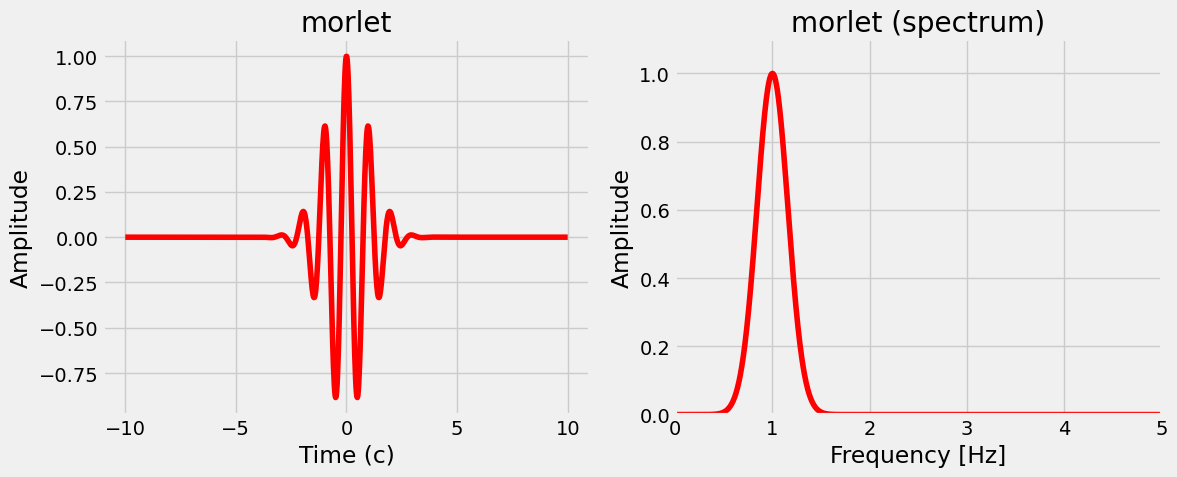

In [18]:
alpha_metodichka = np.sqrt(2.0)

w_0_metodichka = 2 * np.pi * 1.0  

t_metodichka = np.linspace(-10, 10, 1000) 


f_metodichka = np.linspace(0, 5, 1000)
w_metodichka = 2 * np.pi * f_metodichka

psi_t = time_morle_wavelet(t_metodichka, alpha=alpha_metodichka, w_0=w_0_metodichka)
psi_w = freq_morle_wavelet(w_metodichka, alpha=alpha_metodichka, w_0=w_0_metodichka)


psi_w_norm = psi_w / (alpha_metodichka * np.sqrt(np.pi))


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(t_metodichka, np.real(psi_t), 'r', linewidth=4)
plt.title('morlet')
plt.xlabel('Time (с)')
plt.ylabel('Amplitude')
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(f_metodichka, psi_w_norm, 'r', linewidth=4) 
plt.title('morlet (spectrum)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.xlim(0, 5)
plt.ylim(0, 1.1)
plt.grid(True)

plt.tight_layout()
plt.show()

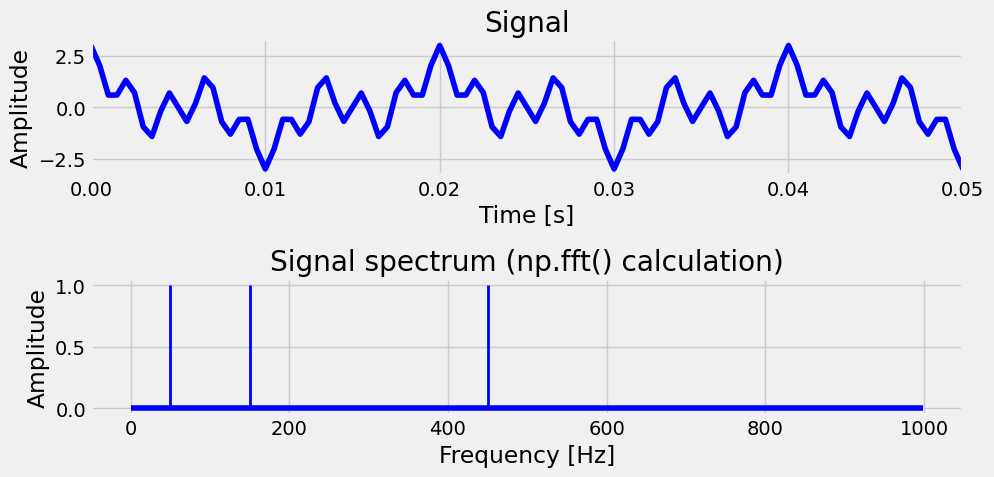

In [19]:
t_vals = np.arange(0, 1, dt_1)
signal_vals = signal_1(t_vals)

np.random.seed(42)
N = signal_vals.shape[-1]

spectrum_fft = np.fft.fft(signal_vals)

N = signal_vals.shape[-1]

freq = np.fft.fftfreq(N, dt_1)

plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(t_vals, signal_vals, 'b')
plt.title('Signal')
plt.xlabel('Time [s]')
plt.xlim(0, 0.05)
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
markerline, stemlines, baseline = plt.stem(freq[:N//2], 2/N * np.abs(spectrum_fft[:N//2]))

plt.setp(stemlines, color='blue', linewidth=2) 
plt.setp(markerline, color='red', markersize=0)
plt.setp(baseline, color='blue')

plt.title('Signal spectrum (np.fft() calculation)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [20]:
frequencies_hz = np.array([f_1, f_2, f_3])
w_0_s = 2 * np.pi * frequencies_hz

t_wavelet = np.arange(-0.05, 0.05, dt_1)

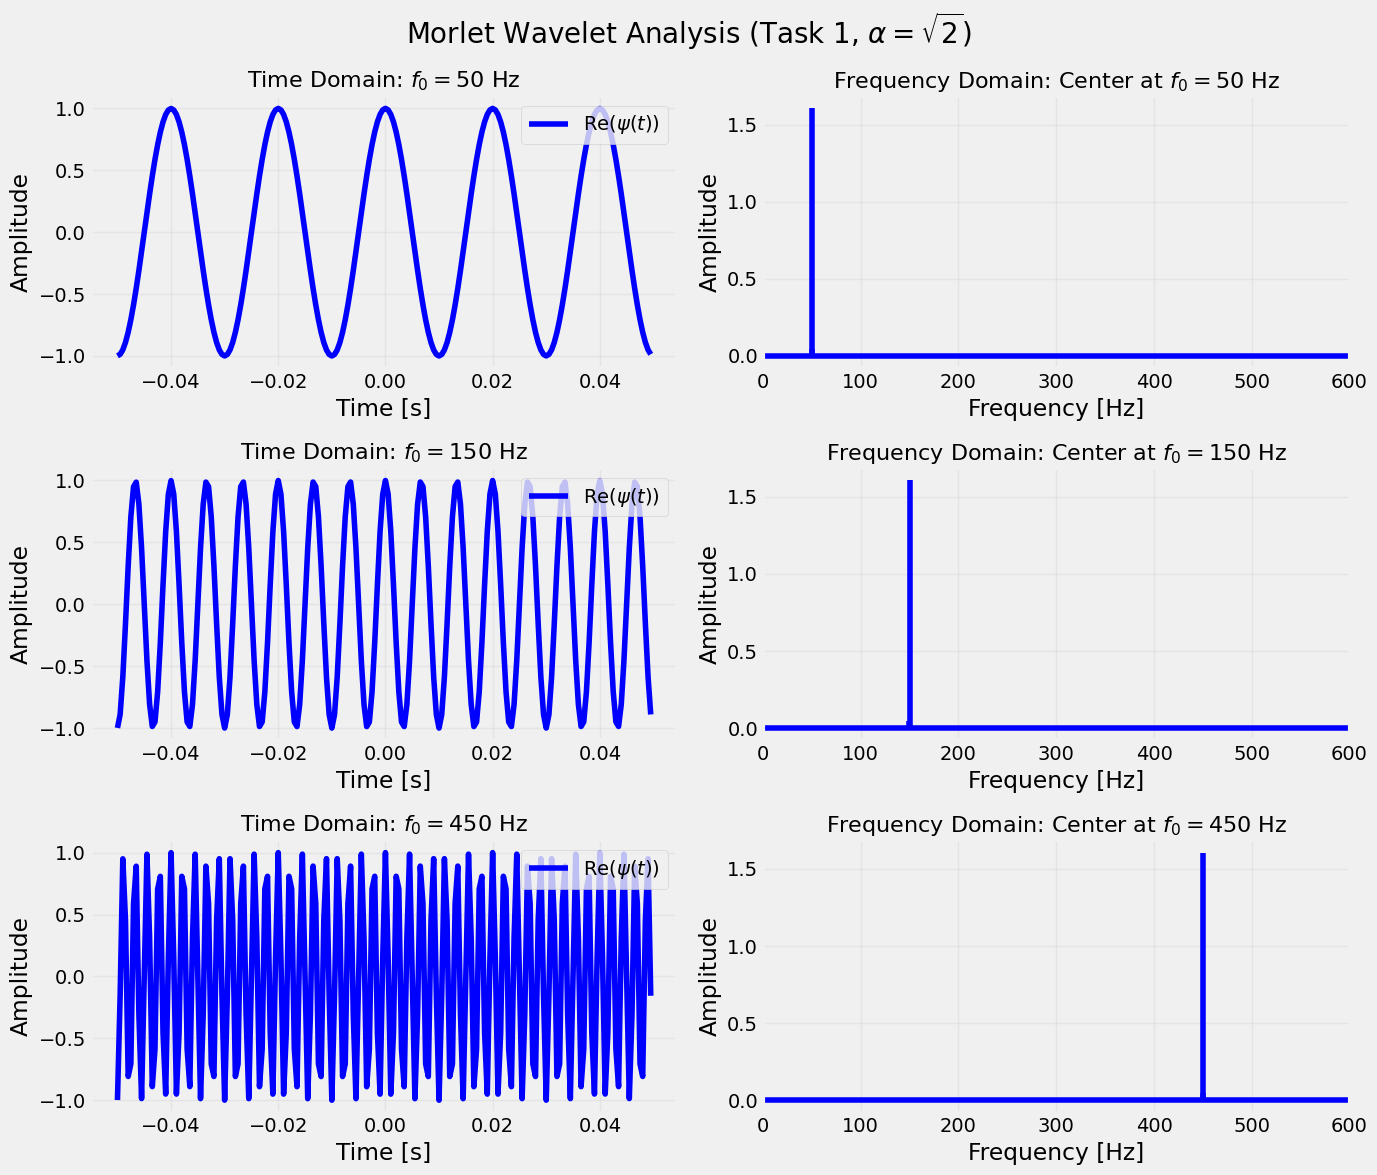

In [21]:
alpha_fixed = np.sqrt(2.0) 
f_axis = np.linspace(0, 600, 1000)
w_axis = 2 * np.pi * f_axis
numb_show = len(w_0_s)

plt.figure(figsize=(14, 4 * numb_show))
plt.suptitle(rf'Morlet Wavelet Analysis (Task 1, $\alpha=\sqrt{{2}}$)', fontsize=20)

for i, w0_val in enumerate(w_0_s):

    psi_t = time_morle_wavelet(t_wavelet, alpha=alpha_fixed, w_0=w0_val)
    psi_w = freq_morle_wavelet(w_axis, alpha=alpha_fixed, w_0=w0_val)
    
    plt.subplot(numb_show, 2, 2 * i + 1)
    plt.plot(t_wavelet, np.real(psi_t), 'b', linewidth=4, label=r'Re($\psi(t)$)')
    
    plt.title(rf'Time Domain: $f_0 = {frequencies_hz[i]:.0f}$ Hz', fontsize=16)
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.subplot(numb_show, 2, 2 * i + 2)
    

    markerline, stemlines, baseline = plt.stem(f_axis, psi_w)

    plt.setp(stemlines, color='b', linewidth=4) 
    plt.setp(markerline, markersize=0)          
    plt.setp(baseline, color='b', linewidth=4)
    
    plt.title(rf'Frequency Domain: Center at $f_0 = {frequencies_hz[i]:.0f}$ Hz', fontsize=16)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude')
    plt.xlim(0, 600)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task2
- Реализовать вейвлет "Мексиканская шляпа" во временном пространстве $\psi(t)$.
- Реализовать вейвлет "Мексиканская шляпа" в частотном пространстве $\psi(\omega)$. Это можно сделать используя обратное преобразование Фурье от $\psi(t)$ или воспользоваться формулой (4).

$$\psi(t) = \left( 1 - \frac{(t - t_0)^2}{\sigma^2} \right) e^{-\frac{(t - t_0)^2}{2\sigma^2}} \cdot e^{i\omega_0 t} \quad (3)$$

$$\hat{\psi}(\omega) = (\omega - \omega_0)^2 e^{-\frac{(\omega - \omega_0)^2 \sigma^2}{2}} \quad (4)$$

Где:

* $t_0$ — это сдвиг по времени (если требуется),
* $e^{i\omega_0 t}$ — гармоническая осцилляция с центральной частотой $\omega_0$.

Используя формулу "Мексиканская шляпа", выясните, как сместить основную частоту фильтрации. Объясните, как выбор основной частоты влияет на фильтрацию сигнала и на поведение вейвлета. Постройте графики временной и частотной формы вейвлета Морле при разных значениях основной частоты фильтрации.

In [22]:
def time_mexican_hat_wavelet(t: npt.ArrayLike,
                             sigma: float = 1.0,
                             w_0: float = 0.0,
                             t_0: float = 0.0) -> np.ndarray:
    """
    Generates the complex Mexican hat wavelet.

    t : npt.ArrayLike
        The time vector (array of time points) where the wavelet is evaluated.
    sigma : float
        Width parameter (scale).
    w_0 : float
        Central angular frequency for harmonic oscillation.
    t_0 : float
        Time shift (translation).
    """
    
    t = np.asarray(t)

    if t.ndim != 1:
        raise ValueError(f"Invalid array dimensions. "
                         f"Expected one-dimensional sequence, but got ndim={t.ndim}.")
    
    fst_factor = (1 - (t - t_0)**2 / sigma**2) 
    
    snd_factor = np.exp(-(t - t_0)**2 / (2 * sigma**2))
    
    harmonic_oscillation = np.exp(1j * w_0 * t)
    
    return fst_factor * snd_factor * harmonic_oscillation

In [23]:
def freq_mexican_hat_wavelet(w: npt.ArrayLike,
                             sigma: float = 1.0,
                             w_0: float = 0.0) -> np.ndarray:
    """
    Generates the Mexican hat wavelet in the frequency domain (spectrum).

    w : npt.ArrayLike
        Angular frequency vector (omega).
    sigma : float
        Width parameter. In the frequency domain, it inversely 
        affects the bandwidth.
    w_0 : float
        The central angular frequency shift.
    """
    w = np.asarray(w)
    
    if w.ndim != 1:
        raise ValueError(f"Invalid array dimensions. "
                         f"Expected one-dimensional sequence, but got ndim={w.ndim}.")

    fst_factor = (w - w_0) ** 2
    exponent = np.exp(-((w - w_0)**2 * sigma**2) / 2)
    
    return fst_factor * exponent

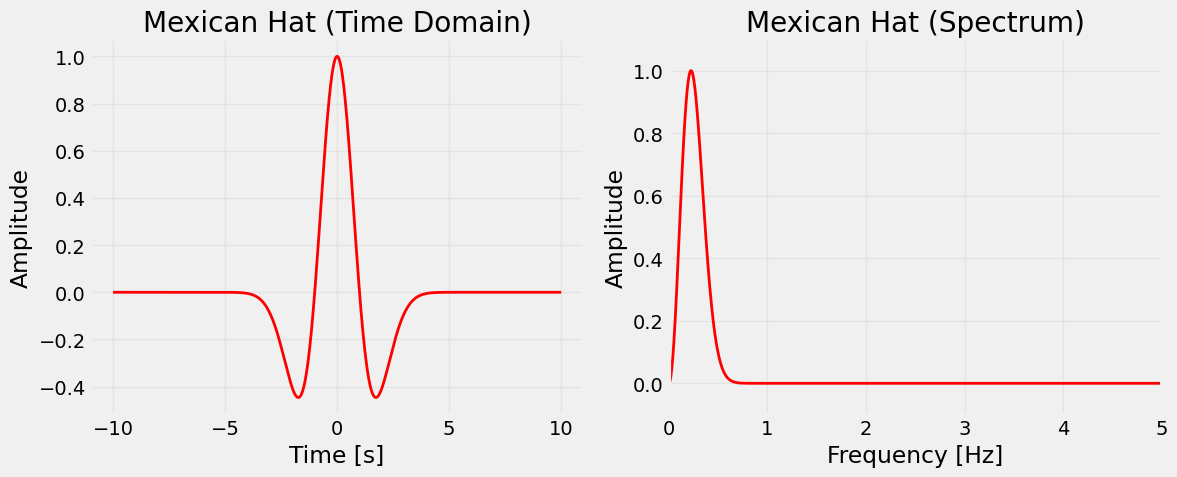

In [24]:
sigma_val = 1.0 
w_0_val = 0 

t_axis = np.linspace(-10, 10, 1000) 
f_axis = np.linspace(0, 5, 1000)
w_axis = 2 * np.pi * f_axis

psi_t = time_mexican_hat_wavelet(t_axis, sigma=sigma_val, w_0=w_0_val)
psi_w = freq_mexican_hat_wavelet(w_axis, sigma=sigma_val, w_0=w_0_val)

psi_w_norm = psi_w / np.max(psi_w) if np.max(psi_w) != 0 else psi_w

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_axis, np.real(psi_t), 'r', linewidth=2) 
plt.title('Mexican Hat (Time Domain)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(f_axis, psi_w_norm, 'r', linewidth=2) 
plt.title('Mexican Hat (Spectrum)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.xlim(0, 5)
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_25126/1431760029.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


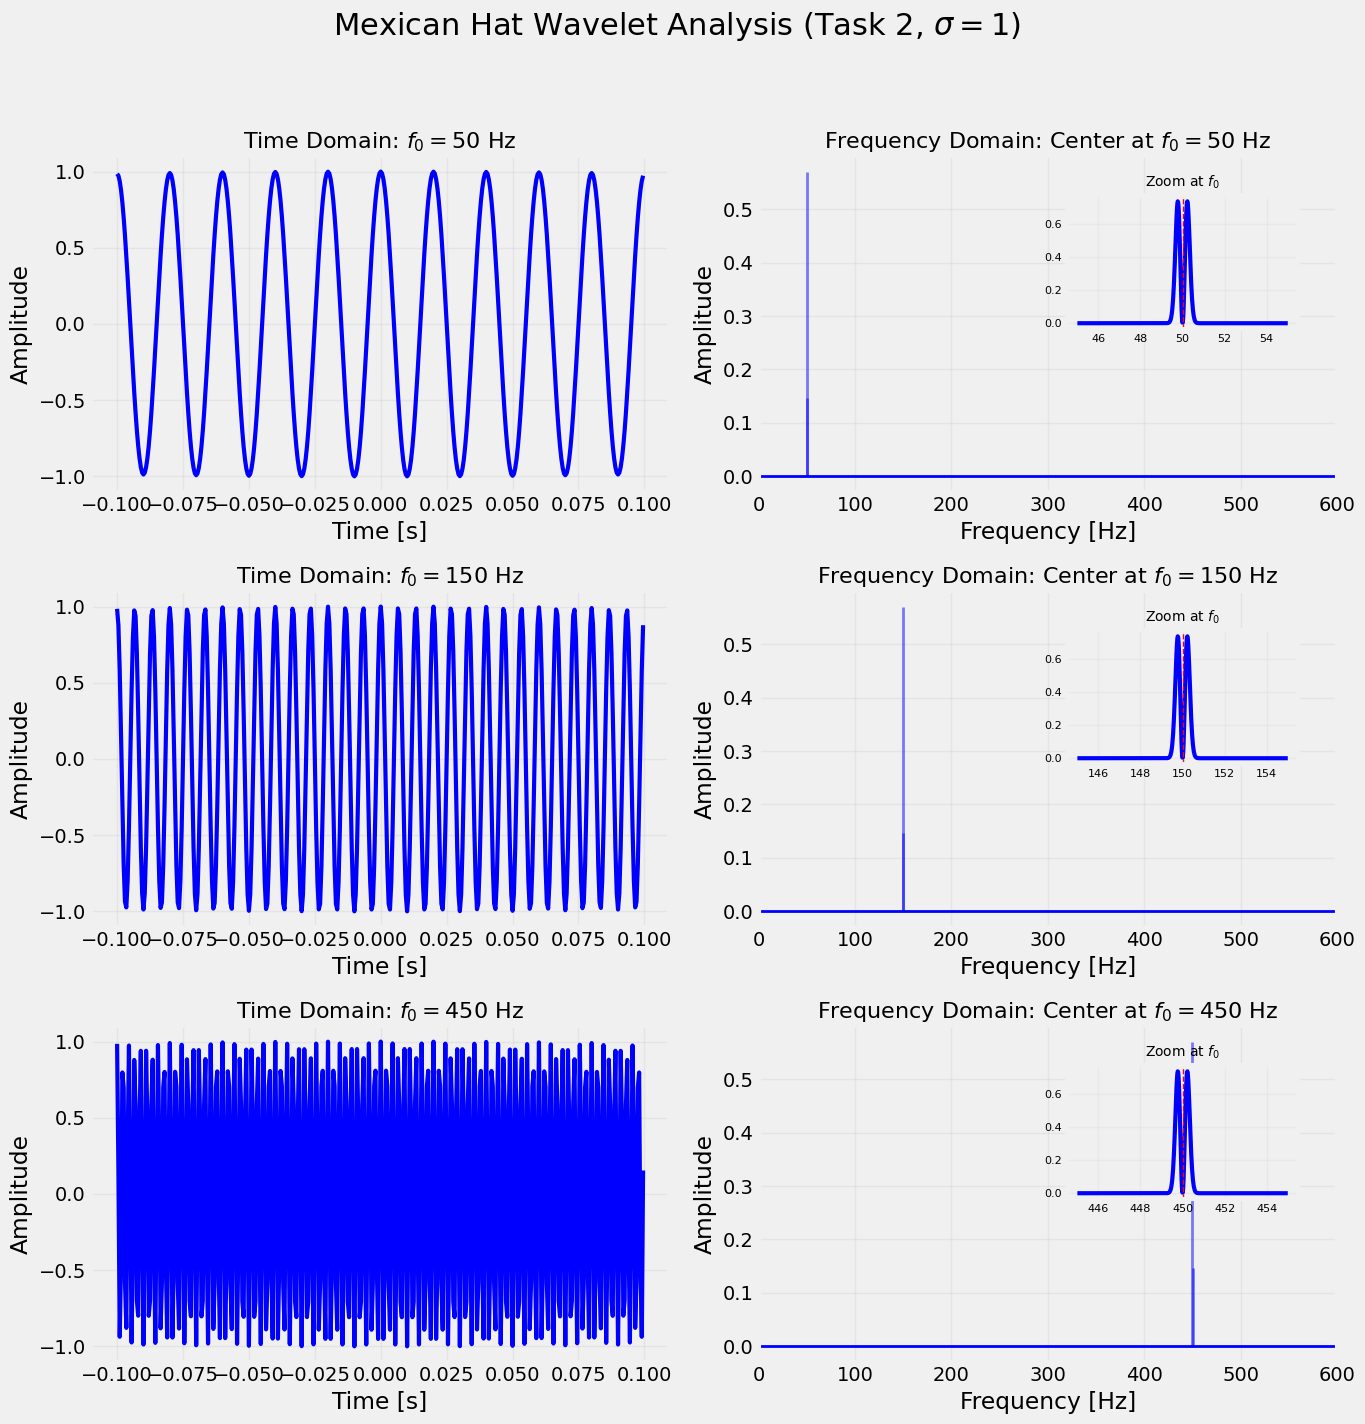

In [25]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sigma_fixed = 1.0  
frequencies_hz = np.array([50, 150, 450]) 
w_0_s = 2 * np.pi * frequencies_hz

t_wavelet = np.arange(-0.1, 0.1, dt_1) 

f_axis = np.linspace(0, 600, 1000)
w_axis = 2 * np.pi * f_axis
numb_show = len(w_0_s)

plt.figure(figsize=(14, 5 * numb_show))
plt.suptitle(rf'Mexican Hat Wavelet Analysis (Task 2, $\sigma=1$)', fontsize=22)

for i, w0_val in enumerate(w_0_s):
    psi_t = time_mexican_hat_wavelet(t_wavelet, sigma=sigma_fixed, w_0=w0_val)
    psi_w = freq_mexican_hat_wavelet(w_axis, sigma=sigma_fixed, w_0=w0_val)
    
    plt.subplot(numb_show, 2, 2 * i + 1)
    plt.plot(t_wavelet, np.real(psi_t), 'b', linewidth=3)
    plt.title(rf'Time Domain: $f_0 = {frequencies_hz[i]:.0f}$ Hz', fontsize=16)
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)

    ax = plt.subplot(numb_show, 2, 2 * i + 2)
    
    markerline, stemlines, baseline = plt.stem(f_axis, np.abs(psi_w)) 
    plt.setp(stemlines, color='b', linewidth=2, alpha=0.5) 
    plt.setp(markerline, markersize=0)           
    plt.setp(baseline, color='b', linewidth=2)
    
    plt.title(rf'Frequency Domain: Center at $f_0 = {frequencies_hz[i]:.0f}$ Hz', fontsize=16)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude')
    plt.xlim(0, 600)
    plt.grid(True, alpha=0.3)

    ax_ins = inset_axes(ax, width="40%", height="40%", loc='upper right', borderpad=2)
    
    f_zoom = np.linspace(frequencies_hz[i] - 5, frequencies_hz[i] + 5, 500)
    w_zoom = 2 * np.pi * f_zoom
    psi_w_zoom = freq_mexican_hat_wavelet(w_zoom, sigma=sigma_fixed, w_0=w0_val)
    
    ax_ins.plot(f_zoom, np.abs(psi_w_zoom), 'b', linewidth=3)
    
    ax_ins.axvline(x=frequencies_hz[i], color='r', linestyle='--', linewidth=1)
    
    ax_ins.set_title("Zoom at $f_0$", fontsize=10)
    ax_ins.tick_params(labelsize=8)
    ax_ins.grid(True, alpha=0.2)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Task3

Реализовать вейвлет Хаара во временном пространстве $\psi(t)$. Вейвлет состоит из двух прямоугольных импульсов: положительного для интервала $0 \le t < 0.5$ и отрицательного для интервала $0.5 \le t < 1$, и может быть представлен согласно формуле (5).

$$\psi(t) = \begin{cases} 1, & 0 \le t < 0.5, \\ -1, & 0.5 \le t < 1, \\ 0, & \text{иначе}. \end{cases} \quad (5)$$

В частотной области вейвлет Хаара $\hat{\psi}(\omega)$ может быть получен с помощью преобразования Фурье от формулы (5) или используя формулу (6).

$$\hat{\psi}(\omega) = 2i \sin\left(\frac{\omega}{2}\right) e^{-i\omega/2} \quad (6)$$

Чтобы изменить центральную частоту фильтрации, мы можем применить масштабирование согласно формуле (7). Если мы хотим увеличить центральную частоту, нужно уменьшить временной масштаб и наоборот. Масштабирование во временной области приводит к изменению частотных характеристик в частотной области согласно формуле (8).

$$\psi_a(t) = \frac{1}{\sqrt{a}}\psi\left(\frac{t}{a}\right) \quad (7)$$

$$\hat{\psi}_a(\omega) = \sqrt{a}\hat{\psi}(a\omega) \quad (8)$$

* При $a < 1$, основной вейвлет сжимается, что увеличивает центральную частоту.
* При $a > 1$, вейвлет расширяется, что уменьшает центральную частоту.

Постройте графики временной и частотной формы вейвлета Хаара при разных значениях основной частоты фильтрации.

In [26]:
from functools import wraps

def scale_time_wavelet(func):
    @wraps(func)
    def wrapper(t: npt.ArrayLike, a: float = 1.0) -> np.ndarray:
        if a <= 0:
            raise ValueError("Scale factor 'a' must be positive.")
        
        t = np.asarray(t)
        if t.ndim != 1:
            raise ValueError(
                f"Invalid array dimensions. "
                f"Expected one-dimensional sequence, but got ndim={t.ndim}."
            )
        
        return (1.0 / np.sqrt(a)) * func(t / a)
    
    return wrapper


def scale_freq_wavelet(func):
    @wraps(func)
    def wrapper(w: npt.ArrayLike, a: float = 1.0) -> np.ndarray:
        if a <= 0:
            raise ValueError("Scale factor 'a' must be positive.")
        
        w = np.asarray(w)
        if w.ndim != 1:
            raise ValueError(
                f"Invalid array dimensions. "
                f"Expected one-dimensional sequence, but got ndim={w.ndim}."
            )
        
        return np.sqrt(a) * func(a * w)
    
    return wrapper

In [27]:
@scale_time_wavelet
def time_haar_wavelet(t: npt.ArrayLike) -> np.ndarray:
    """
    Generates the Haar's wavelet in time domain.

    t : npt.ArrayLike
        The time vector (array of time points) where the wavelet is evaluated.
    """
    
    t = np.asarray(t)

    if t.ndim != 1:
        raise ValueError(f"Invalid array dimensions. "
                         f"Expected one-dimensional sequence, but got ndim={t.ndim}.")
    
    psi_t = np.zeros_like(t, dtype=float)
    psi_t[(t >= 0) & (t < 0.5)] = 1.0
    psi_t[(t >= 0.5) & (t < 1.0)] = -1.0
    
    return psi_t

In [28]:
@scale_freq_wavelet
def freq_haar_wavelet(w: npt.ArrayLike) -> np.ndarray:
    """
    Generates the Haar's wavelet in freq domain.
    """
    w = np.asarray(w)

    if w.ndim != 1:
        raise ValueError(
            f"Invalid array dimensions. "
            f"Expected one-dimensional sequence, but got ndim={w.ndim}."
        )

    return 2j * np.sin(w / 2) * np.exp(-1j * w / 2)

/home/ilya-trushkin/Desktop/digital_signal_processing/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ilya-trushkin/Desktop/digital_signal_processing/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


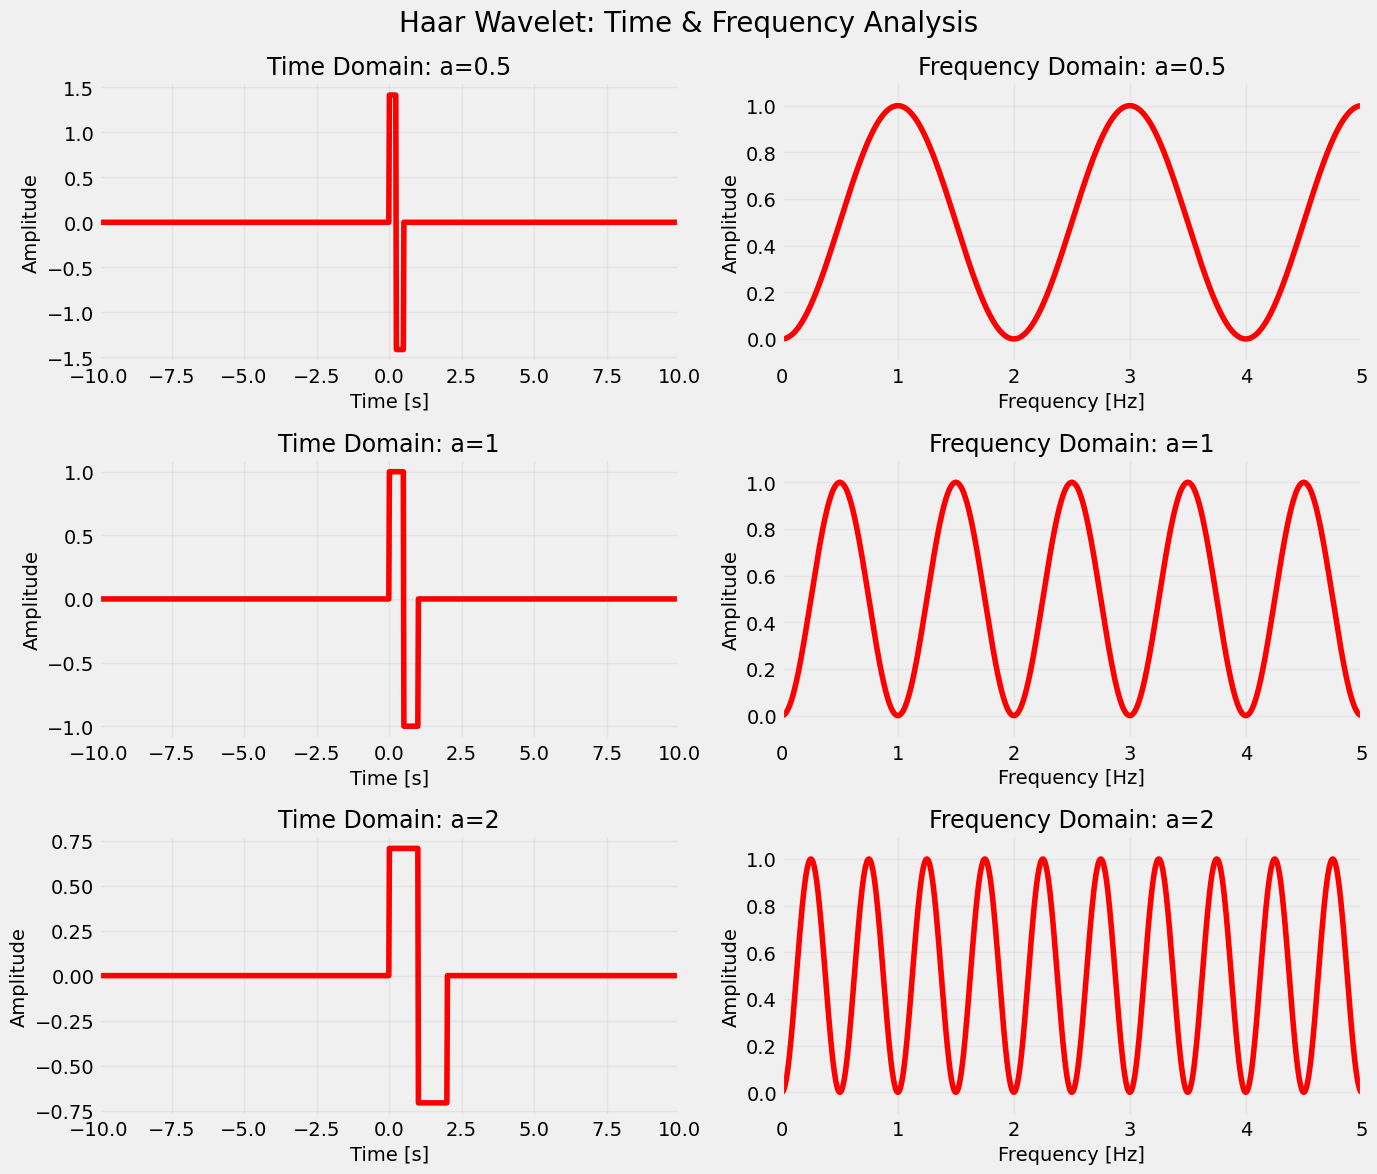

In [29]:
a_coefs = [0.5, 1, 2]
numb_show = len(a_coefs)

t_axis = np.linspace(-10, 10, 1000)
f_axis = np.linspace(0, 5, 1000)
w_axis = 2 * np.pi * f_axis

plt.figure(figsize=(14, 4 * numb_show))
plt.suptitle('Haar Wavelet: Time & Frequency Analysis', fontsize=20)

for i, a in enumerate(a_coefs):
    psi_t = time_haar_wavelet(t_axis, a=a)
    psi_w = freq_haar_wavelet(w_axis, a=a)

    psi_w_norm = psi_w / np.max(np.abs(psi_w)) if np.max(np.abs(psi_w)) != 0 else psi_w

    plt.subplot(numb_show, 2, 2 * i + 1)
    plt.plot(t_axis, psi_t, 'r', linewidth=4)
    plt.title(rf'Time Domain: a={a}', fontsize=17)
    plt.xlabel('Time [s]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xlim(-10, 10)

    plt.subplot(numb_show, 2, 2 * i + 2)
    plt.plot(f_axis, psi_w_norm, 'r', linewidth=4)
    plt.title(rf'Frequency Domain: a={a}', fontsize=17)
    plt.xlabel('Frequency [Hz]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 5)
    plt.ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

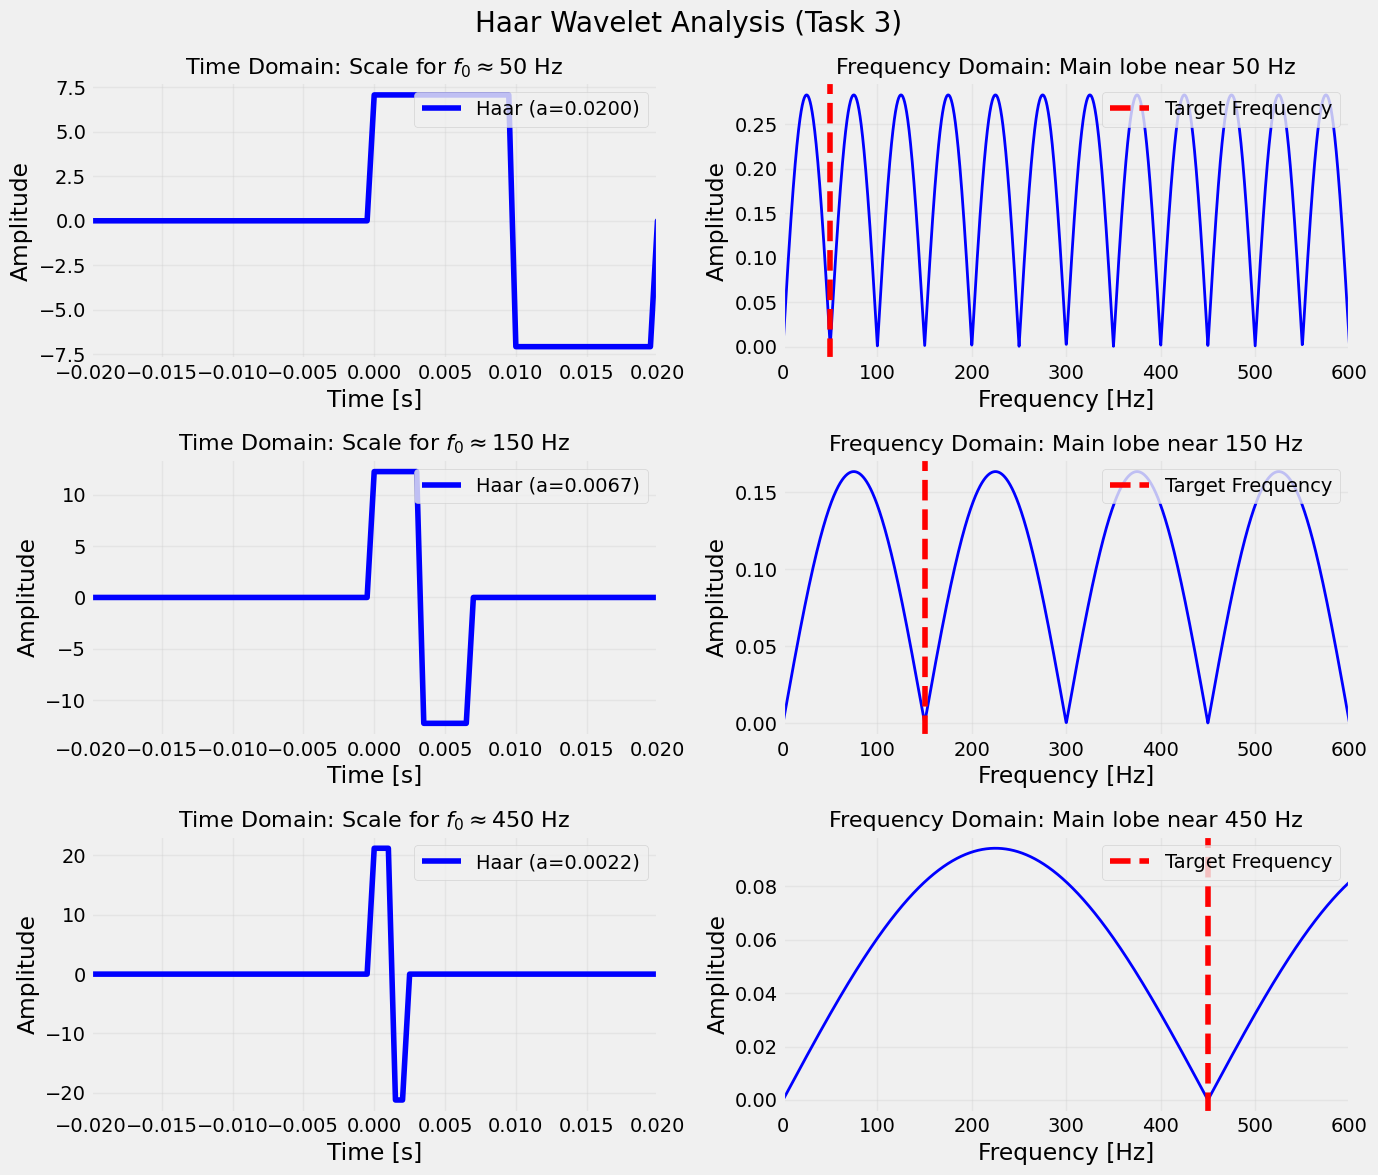

In [30]:
a_values = 1.0 / frequencies_hz 

f_axis = np.linspace(0, 600, 2000) 
w_axis = 2 * np.pi * f_axis
numb_show = len(a_values)

plt.figure(figsize=(14, 4 * numb_show))
plt.suptitle(rf'Haar Wavelet Analysis (Task 3)', fontsize=20)

for i, a_val in enumerate(a_values):
    psi_t = time_haar_wavelet(t_wavelet, a=a_val)
    psi_w = freq_haar_wavelet(w_axis, a=a_val)
    
    psi_w_abs = np.abs(psi_w)
    
    plt.subplot(numb_show, 2, 2 * i + 1)
    plt.plot(t_wavelet, psi_t, 'b', linewidth=4, label=f'Haar (a={a_val:.4f})')
    
    plt.title(rf'Time Domain: Scale for $f_0 \approx {frequencies_hz[i]:.0f}$ Hz', fontsize=16)
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.xlim(-0.02, 0.02) 
    plt.grid(True, alpha=0.3)

    plt.subplot(numb_show, 2, 2 * i + 2)
    
    plt.plot(f_axis, psi_w_abs, 'b', linewidth=2)
    
    plt.axvline(x=frequencies_hz[i], color='r', linestyle='--', label='Target Frequency')
    
    plt.title(rf'Frequency Domain: Main lobe near {frequencies_hz[i]:.0f} Hz', fontsize=16)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude')
    plt.xlim(0, 600)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task4

- Реализовать свертку сигнала с вейвлетами Морле, вейвлетом "Мексиканская шляпа" и вейвлетом Хаара. 
- Осуществить фильтрацию сигналов с помощью этих 3-х вейвлетов для 
  - (а) сигнала с тремя выделенными частотами, 
  - (б) сигнала прямоугольных импульсов с фиксированной частотой. 

Сравнить результаты. Отметить сильные и слабые стороны каждого из вейвлетов.
Добавить шум к сигналам, отметить результаты фильтраций.

In [31]:
f_1 = 50.0
f_2 = 150.0
f_3 = 450.0

Fs = 2000 
dt_1 = 1.0 / Fs

w_1 = 2 * np.pi * f_1
w_2 = 2 * np.pi * f_2
w_3 = 2 * np.pi * f_3

signal_1 = lambda t : np.cos(w_1 * t) + np.cos(w_2 * t) + np.cos(w_3 * t)

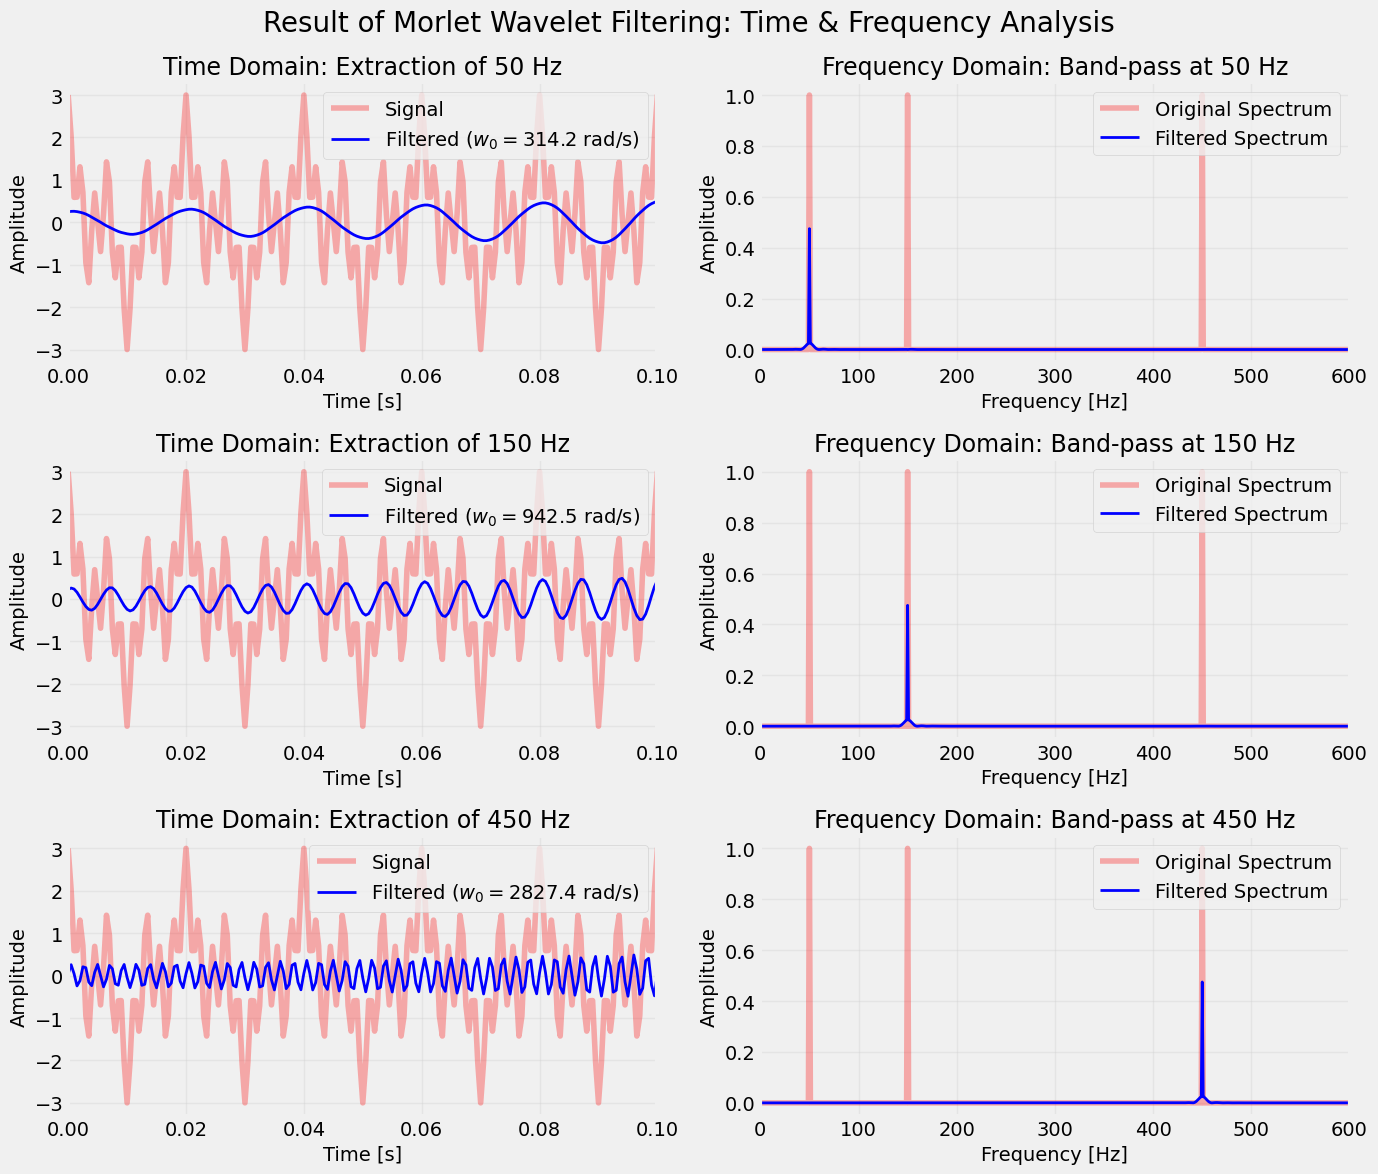

In [32]:
numb_show = len(w_0_s)

plt.figure(figsize=(14, 4 * numb_show))
plt.suptitle('Result of Morlet Wavelet Filtering: Time & Frequency Analysis', fontsize=20)

for i, w0_val in enumerate(w_0_s):

    wavelet = time_morle_wavelet(t_wavelet, w_0=w0_val)
    
    filtered_signal = np.convolve(signal_vals, wavelet, mode='same') / np.sum(np.abs(wavelet))
    
    N = len(signal_vals)
    freq_axis = np.fft.fftfreq(N, dt_1)
    half = N // 2
    
    orig_fft = np.abs(np.fft.fft(signal_vals)) * 2 / N
    filt_fft = np.abs(np.fft.fft(np.real(filtered_signal))) * 2 / N
    
    plt.subplot(numb_show, 2, 2 * i + 1)
    plt.plot(t_vals, signal_vals, 'r', alpha=0.3, label='Signal')
    plt.plot(t_vals, np.real(filtered_signal), 'b', linewidth=2, 
             label=rf'Filtered ($w_0={w0_val:.1f}$ rad/s)')
    
    current_f = w0_val / (2 * np.pi)
    plt.title(rf'Time Domain: Extraction of {current_f:.0f} Hz', fontsize=17)
    plt.xlabel('Time [s]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.legend(loc='upper right')
    plt.xlim(0, 0.1) 
    plt.grid(True, alpha=0.3)

    plt.subplot(numb_show, 2, 2 * i + 2)
    plt.plot(freq_axis[:half], orig_fft[:half], 'r', alpha=0.3, label='Original Spectrum')
    plt.plot(freq_axis[:half], filt_fft[:half], 'b', linewidth=2, label='Filtered Spectrum')
    
    plt.title(rf'Frequency Domain: Band-pass at {current_f:.0f} Hz', fontsize=17)
    plt.xlabel('Frequency [Hz]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.legend(loc='upper right')
    plt.xlim(0, 600) 
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

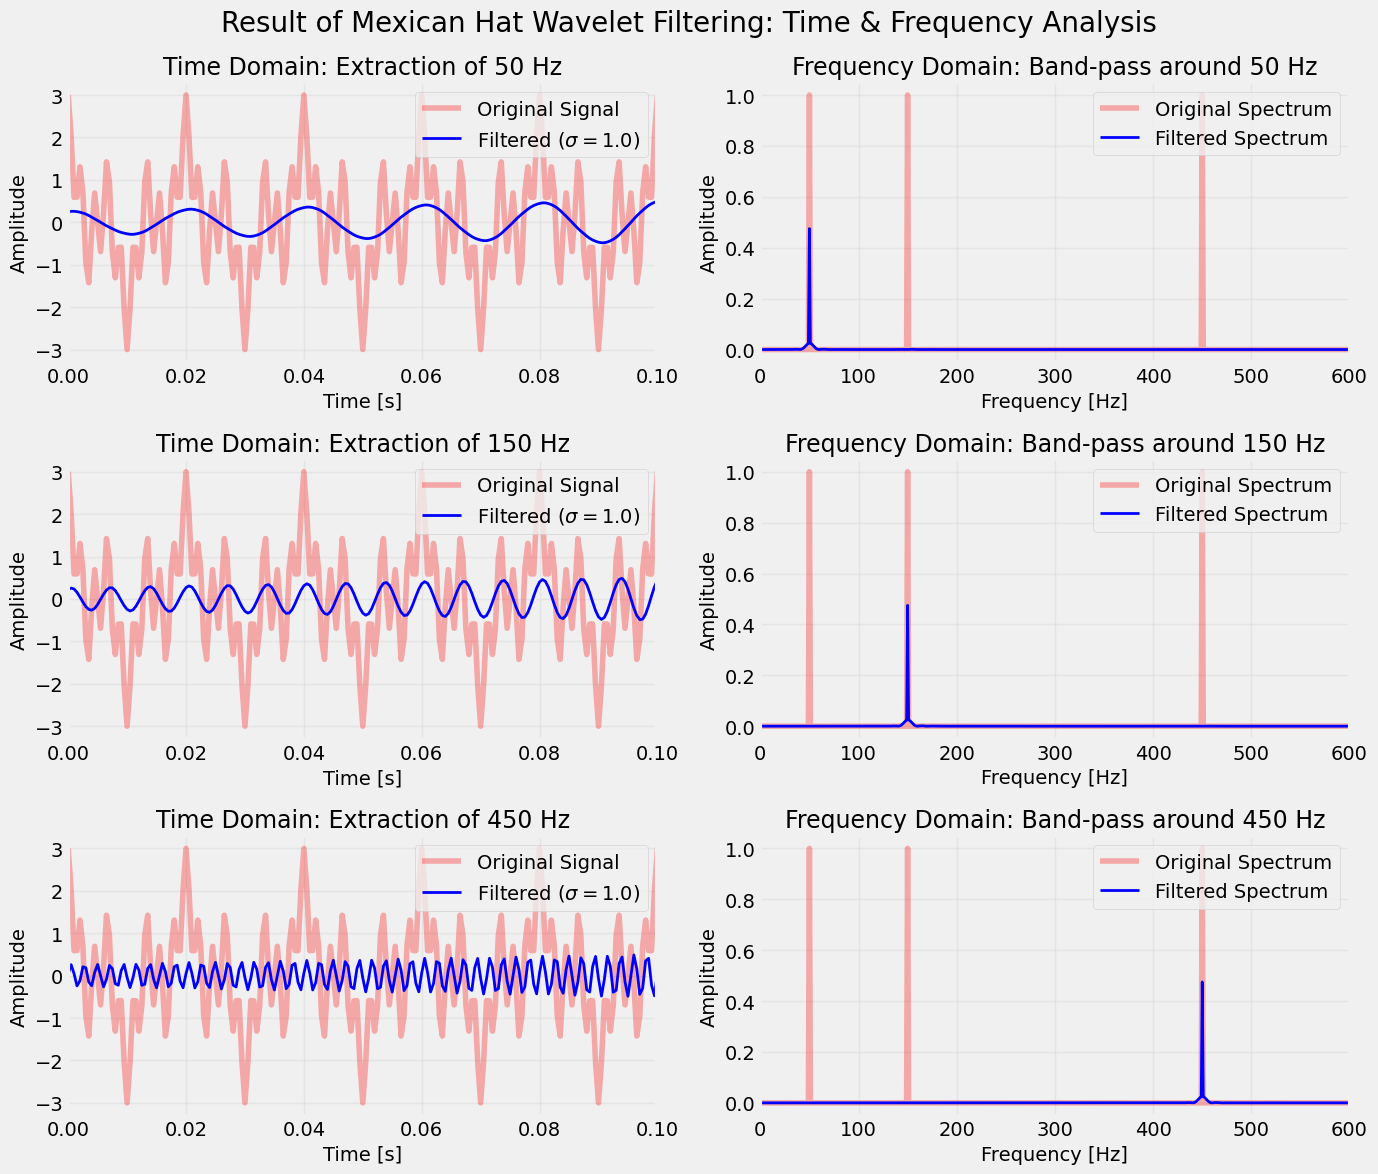

In [33]:
sigma_fixed = 1.0 
numb_show = len(w_0_s)

plt.figure(figsize=(14, 4 * numb_show))
plt.suptitle('Result of Mexican Hat Wavelet Filtering: Time & Frequency Analysis', fontsize=20)

for i, w0_val in enumerate(w_0_s):

    wavelet = time_mexican_hat_wavelet(t_wavelet, sigma=sigma_fixed, w_0=w0_val)
    
    filtered_signal = np.convolve(signal_vals, wavelet, mode='same') / np.sum(np.abs(wavelet))
    
    N = len(signal_vals)
    freq_axis = np.fft.fftfreq(N, dt_1)
    half = N // 2
    
    orig_fft = np.abs(np.fft.fft(signal_vals)) * 2 / N
    filt_fft = np.abs(np.fft.fft(np.real(filtered_signal))) * 2 / N
    
    plt.subplot(numb_show, 2, 2 * i + 1)
    plt.plot(t_vals, signal_vals, 'r', alpha=0.3, label='Original Signal')
    plt.plot(t_vals, np.real(filtered_signal), 'b', linewidth=2, 
             label=rf'Filtered ($\sigma={sigma_fixed}$)')
    
    current_f = w0_val / (2 * np.pi)
    plt.title(rf'Time Domain: Extraction of {current_f:.0f} Hz', fontsize=17)
    plt.xlabel('Time [s]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.legend(loc='upper right')
    plt.xlim(0, 0.1) 
    plt.grid(True, alpha=0.3)

    plt.subplot(numb_show, 2, 2 * i + 2)
    plt.plot(freq_axis[:half], orig_fft[:half], 'r', alpha=0.3, label='Original Spectrum')
    plt.plot(freq_axis[:half], filt_fft[:half], 'b', linewidth=2, label='Filtered Spectrum')
    
    plt.title(rf'Frequency Domain: Band-pass around {current_f:.0f} Hz', fontsize=17)
    plt.xlabel('Frequency [Hz]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.legend(loc='upper right')
    plt.xlim(0, 600) 
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

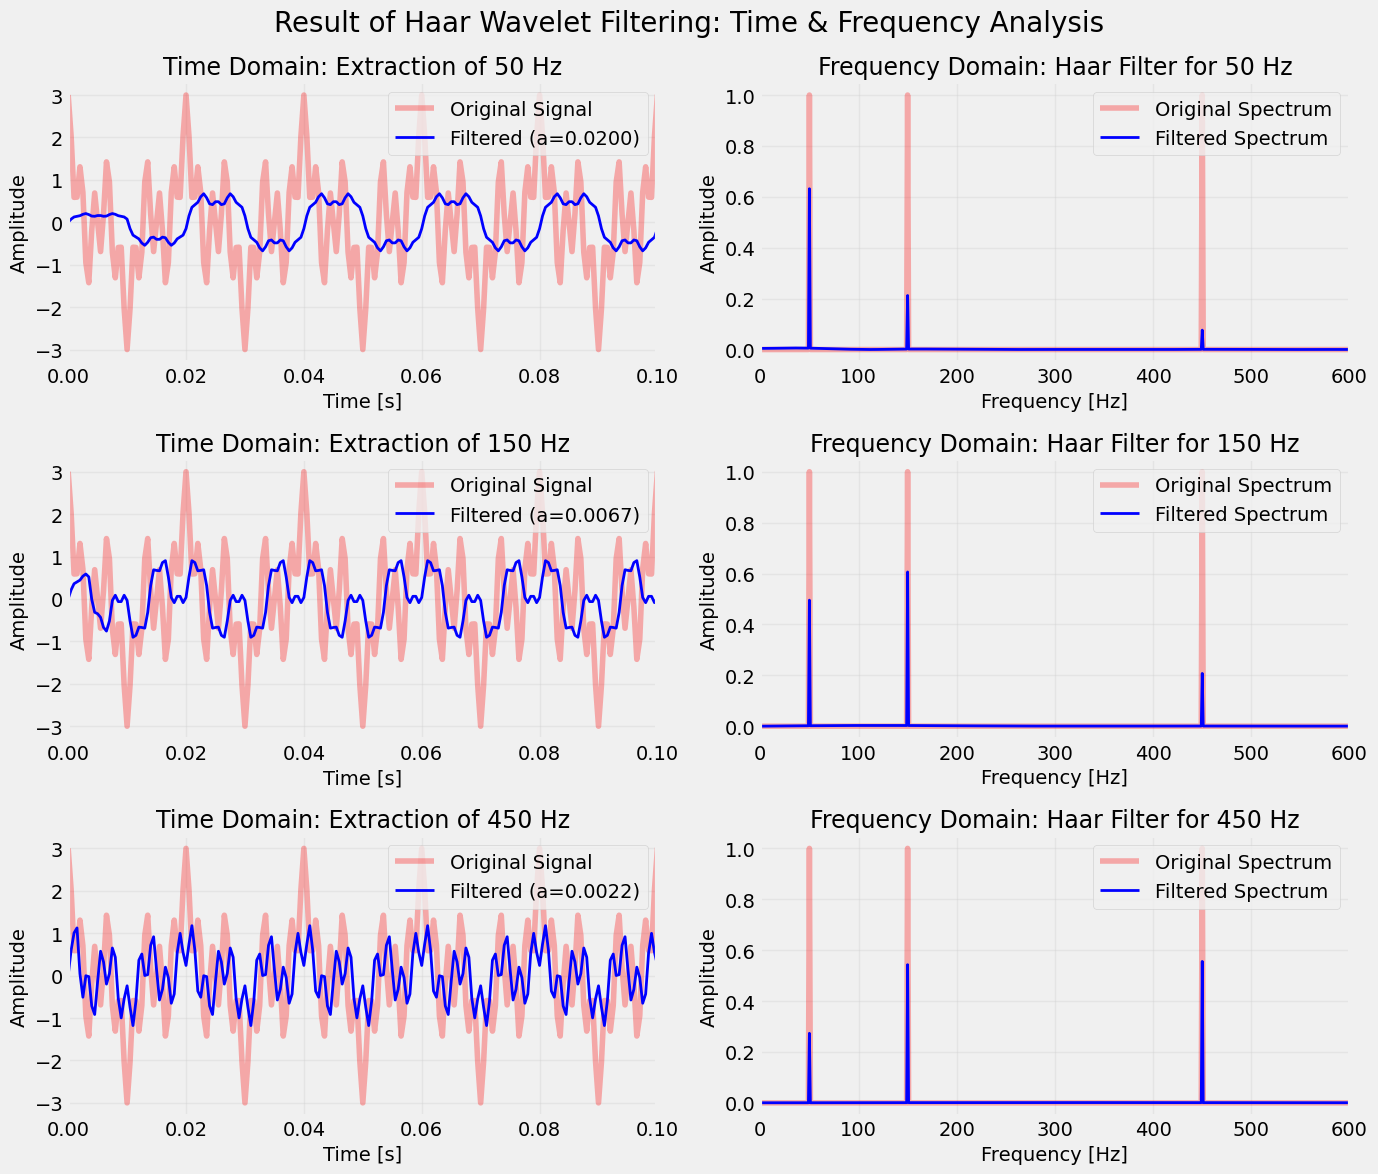

In [34]:
a_values = 1.0 / frequencies_hz 
numb_show = len(a_values)

plt.figure(figsize=(14, 4 * numb_show))
plt.suptitle('Result of Haar Wavelet Filtering: Time & Frequency Analysis', fontsize=20)

for i, a_val in enumerate(a_values):
    wavelet = time_haar_wavelet(t_wavelet, a=a_val)
    
    filtered_signal = np.convolve(signal_vals, wavelet, mode='same') / np.sum(np.abs(wavelet))
    
    N = len(signal_vals)
    freq_axis = np.fft.fftfreq(N, dt_1)
    half = N // 2
    
    orig_fft = np.abs(np.fft.fft(signal_vals)) * 2 / N
    filt_fft = np.abs(np.fft.fft(np.real(filtered_signal))) * 2 / N
    

    plt.subplot(numb_show, 2, 2 * i + 1)
    plt.plot(t_vals, signal_vals, 'r', alpha=0.3, label='Original Signal')
    plt.plot(t_vals, np.real(filtered_signal), 'b', linewidth=2, 
             label=rf'Filtered (a={a_val:.4f})')
    
    current_f = frequencies_hz[i]
    plt.title(rf'Time Domain: Extraction of {current_f:.0f} Hz', fontsize=17)
    plt.xlabel('Time [s]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.legend(loc='upper right')
    plt.xlim(0, 0.1) 
    plt.grid(True, alpha=0.3)

    plt.subplot(numb_show, 2, 2 * i + 2)
    plt.plot(freq_axis[:half], orig_fft[:half], 'r', alpha=0.3, label='Original Spectrum')
    plt.plot(freq_axis[:half], filt_fft[:half], 'b', linewidth=2, label='Filtered Spectrum')
    
    plt.title(rf'Frequency Domain: Haar Filter for {current_f:.0f} Hz', fontsize=17)
    plt.xlabel('Frequency [Hz]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.legend(loc='upper right')
    plt.xlim(0, 600) 
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
T_2 = 2 
f_2 = 1/T_2         
A_2 = 2.0   
Fs_2 = 300 # sampling rate
dt_2 = 1.0 / Fs_2          
w_2 = 2 * np.pi * f_2

meandr = lambda t: A_2 * np.sign(np.sin(w_2 * t))

In [36]:
duration = 2 * T_2

t_vals2 = np.arange(0, duration, dt_1)

meandr_vals = meandr(t_vals2)

In [37]:
frequencies_meandr = np.array([f_2 * 1, f_2 * 3, f_2 * 5]) # 0.5, 1.5 и 2.5 Гц
w_0_s_meandr = 2 * np.pi * frequencies_meandr

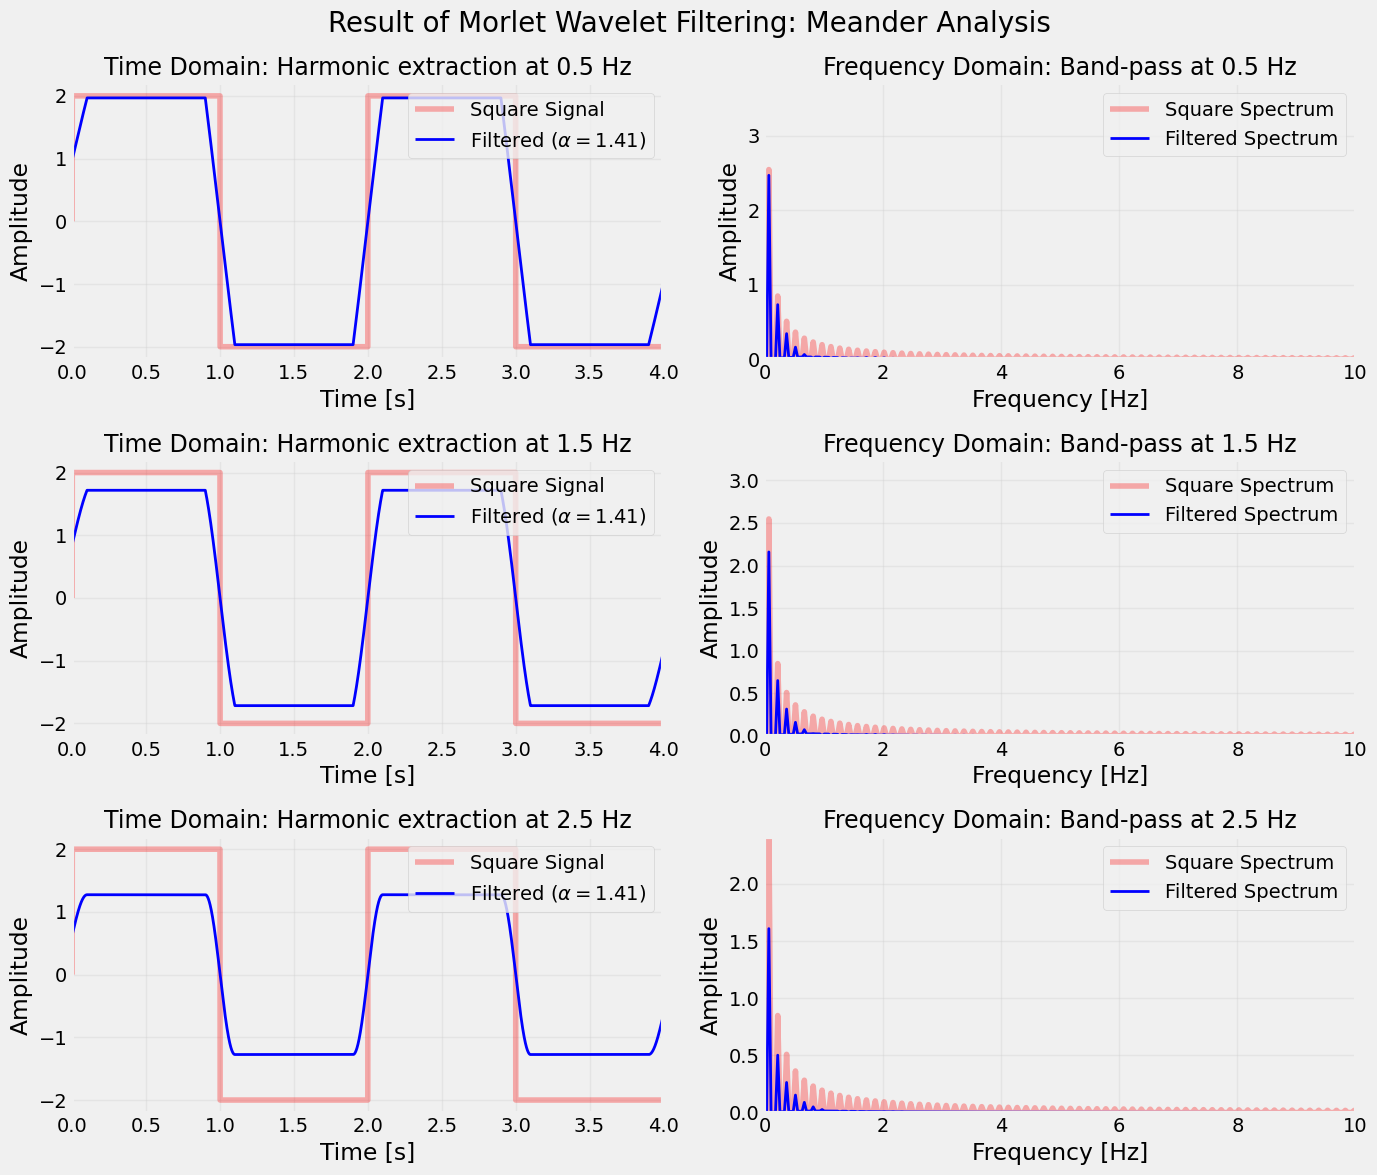

In [38]:

alpha_fixed = np.sqrt(2.0) 
numb_show = len(w_0_s_meandr)

plt.figure(figsize=(14, 4 * numb_show))
plt.suptitle('Result of Morlet Wavelet Filtering: Meander Analysis', fontsize=20)

for i, w0_val in enumerate(w_0_s_meandr):

    wavelet = time_morle_wavelet(t_wavelet, alpha=alpha_fixed, w_0=w0_val)
    
    filtered_signal = np.convolve(meandr_vals, wavelet, mode='same') / np.sum(np.abs(wavelet))
    
    N = len(meandr_vals)
    freq_axis = np.fft.fftfreq(N, dt_2)
    half = N // 2
    
    orig_fft = np.abs(np.fft.fft(meandr_vals)) * 2 / N
    filt_fft = np.abs(np.fft.fft(np.real(filtered_signal))) * 2 / N
    
    plt.subplot(numb_show, 2, 2 * i + 1)
    plt.plot(t_vals2, meandr_vals, 'r', alpha=0.3, label='Square Signal')
    plt.plot(t_vals2, np.real(filtered_signal), 'b', linewidth=2, 
             label=rf'Filtered ($\alpha={alpha_fixed:.2f}$)')
    
    current_f = w0_val / (2 * np.pi)
    plt.title(rf'Time Domain: Harmonic extraction at {current_f:.1f} Hz', fontsize=17)
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.xlim(0, duration) 
    plt.grid(True, alpha=0.3)

    plt.subplot(numb_show, 2, 2 * i + 2)
    plt.plot(freq_axis[:half], orig_fft[:half], 'r', alpha=0.3, label='Square Spectrum')
    plt.plot(freq_axis[:half], filt_fft[:half], 'b', linewidth=2, label='Filtered Spectrum')
    
    plt.title(rf'Frequency Domain: Band-pass at {current_f:.1f} Hz', fontsize=17)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    
    plt.xlim(0, 10) 
    if np.max(filt_fft) > 0:
        plt.ylim(0, np.max(filt_fft) * 1.5) 
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

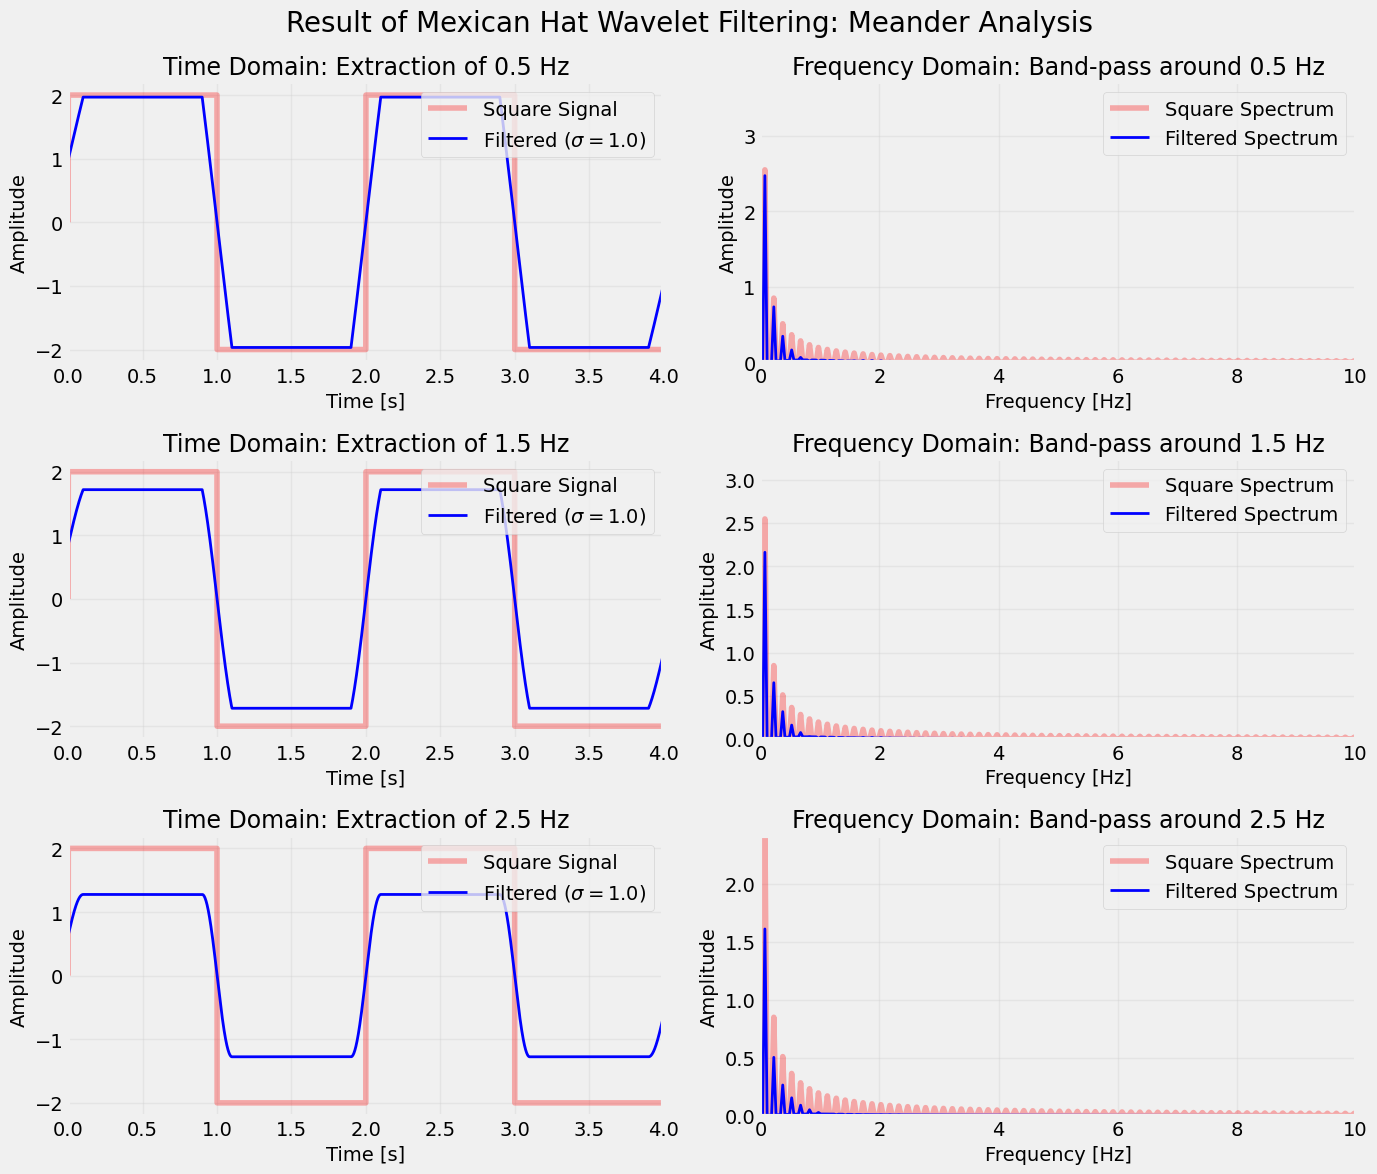

In [39]:
sigma_fixed = 1.0 
numb_show = len(w_0_s_meandr)

plt.figure(figsize=(14, 4 * numb_show))
plt.suptitle('Result of Mexican Hat Wavelet Filtering: Meander Analysis', fontsize=20)

for i, w0_val in enumerate(w_0_s_meandr):

    wavelet = time_mexican_hat_wavelet(t_wavelet, sigma=sigma_fixed, w_0=w0_val)
    

    filtered_signal = np.convolve(meandr_vals, wavelet, mode='same') / np.sum(np.abs(wavelet))
    
    N = len(meandr_vals)
    freq_axis = np.fft.fftfreq(N, dt_2)
    half = N // 2
    
    orig_fft = np.abs(np.fft.fft(meandr_vals)) * 2 / N
    filt_fft = np.abs(np.fft.fft(np.real(filtered_signal))) * 2 / N
    
    plt.subplot(numb_show, 2, 2 * i + 1)
    plt.plot(t_vals2, meandr_vals, 'r', alpha=0.3, label='Square Signal')
    plt.plot(t_vals2, np.real(filtered_signal), 'b', linewidth=2, 
             label=rf'Filtered ($\sigma={sigma_fixed}$)')
    
    current_f = w0_val / (2 * np.pi)
    plt.title(rf'Time Domain: Extraction of {current_f:.1f} Hz', fontsize=17)
    plt.xlabel('Time [s]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.legend(loc='upper right')
    plt.xlim(0, duration) 
    plt.grid(True, alpha=0.3)


    plt.subplot(numb_show, 2, 2 * i + 2)
    plt.plot(freq_axis[:half], orig_fft[:half], 'r', alpha=0.3, label='Square Spectrum')
    plt.plot(freq_axis[:half], filt_fft[:half], 'b', linewidth=2, label='Filtered Spectrum')
    
    plt.title(rf'Frequency Domain: Band-pass around {current_f:.1f} Hz', fontsize=17)
    plt.xlabel('Frequency [Hz]', fontsize=14)
    plt.ylabel('Amplitude', fontsize=14)
    plt.legend(loc='upper right')
    
    plt.xlim(0, 10) 
    plt.ylim(0, np.max(filt_fft) * 1.5) 
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

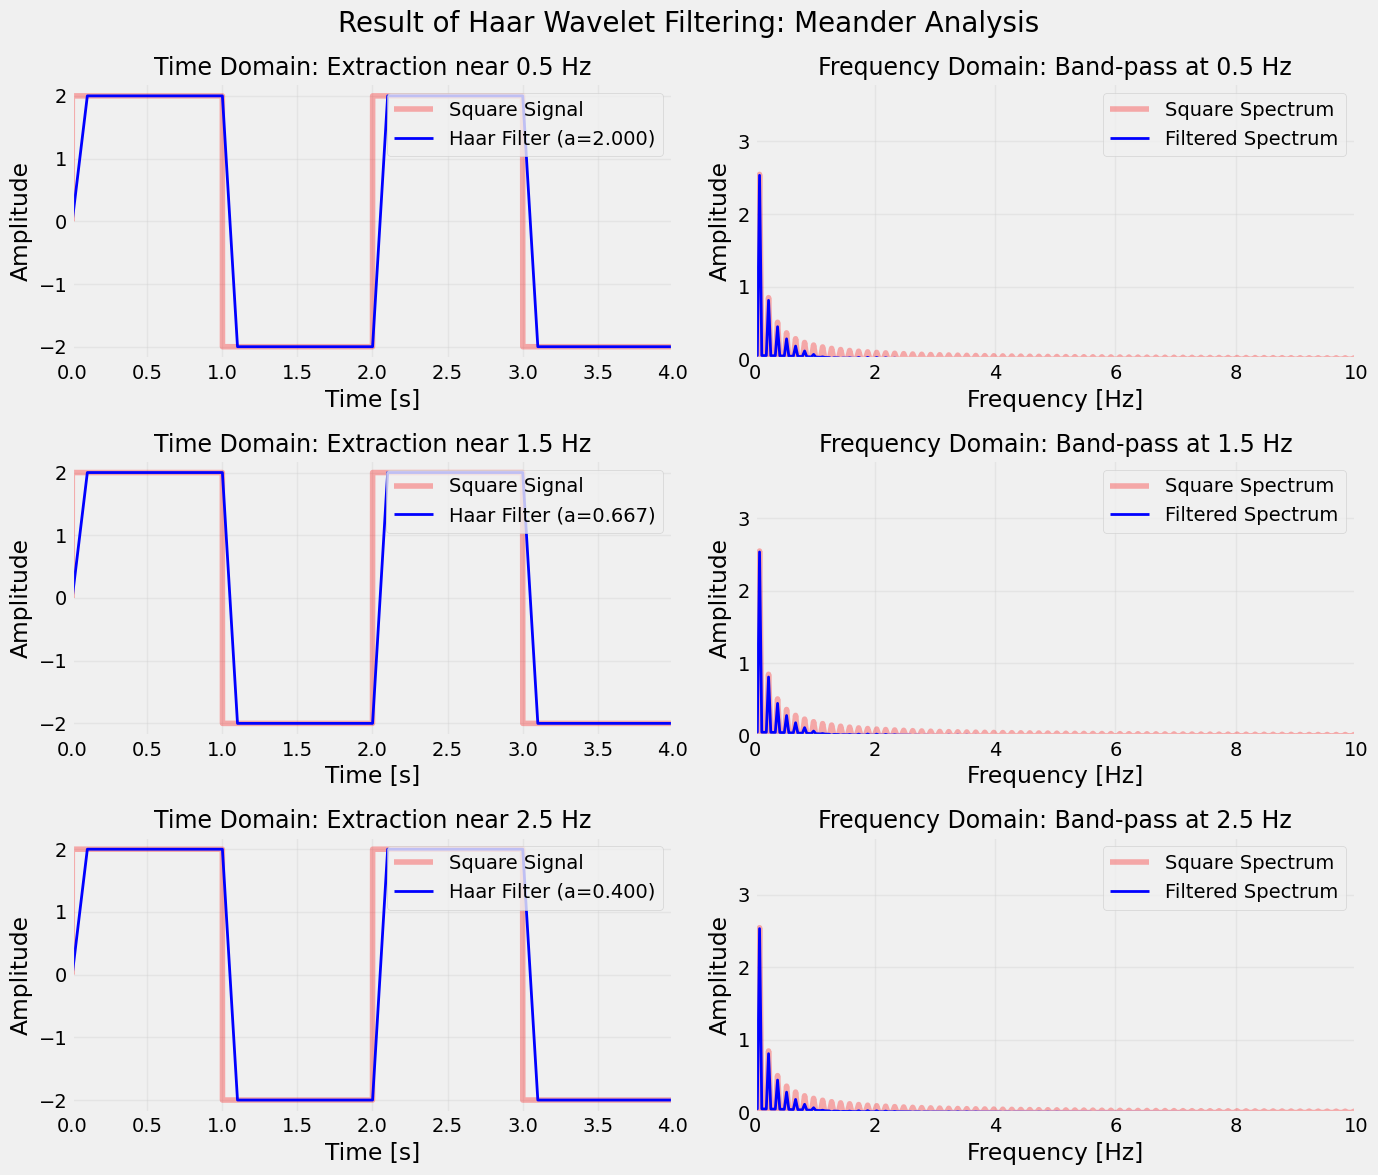

In [40]:
a_values_meandr = 1.0 / (w_0_s_meandr / (2 * np.pi))
numb_show = len(a_values_meandr)

plt.figure(figsize=(14, 4 * numb_show))
plt.suptitle('Result of Haar Wavelet Filtering: Meander Analysis', fontsize=20)

for i, a_val in enumerate(a_values_meandr):
    wavelet = time_haar_wavelet(t_wavelet, a=a_val)
    
    filtered_signal = np.convolve(meandr_vals, wavelet, mode='same') / np.sum(np.abs(wavelet))
    
    N = len(meandr_vals)
    freq_axis = np.fft.fftfreq(N, dt_2)
    half = N // 2
    
    orig_fft = np.abs(np.fft.fft(meandr_vals)) * 2 / N
    filt_fft = np.abs(np.fft.fft(np.real(filtered_signal))) * 2 / N
    
    plt.subplot(numb_show, 2, 2 * i + 1)
    plt.plot(t_vals2, meandr_vals, 'r', alpha=0.3, label='Square Signal')
    plt.plot(t_vals2, np.real(filtered_signal), 'b', linewidth=2, 
             label=rf'Haar Filter (a={a_val:.3f})')
    
    current_f = 1.0 / a_val
    plt.title(rf'Time Domain: Extraction near {current_f:.1f} Hz', fontsize=17)
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.xlim(0, duration) 
    plt.grid(True, alpha=0.3)

    plt.subplot(numb_show, 2, 2 * i + 2)
    plt.plot(freq_axis[:half], orig_fft[:half], 'r', alpha=0.3, label='Square Spectrum')
    plt.plot(freq_axis[:half], filt_fft[:half], 'b', linewidth=2, label='Filtered Spectrum')
    
    plt.title(rf'Frequency Domain: Band-pass at {current_f:.1f} Hz', fontsize=17)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    
    plt.xlim(0, 10) 
    if np.max(filt_fft) > 0:
        plt.ylim(0, np.max(filt_fft) * 1.5)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

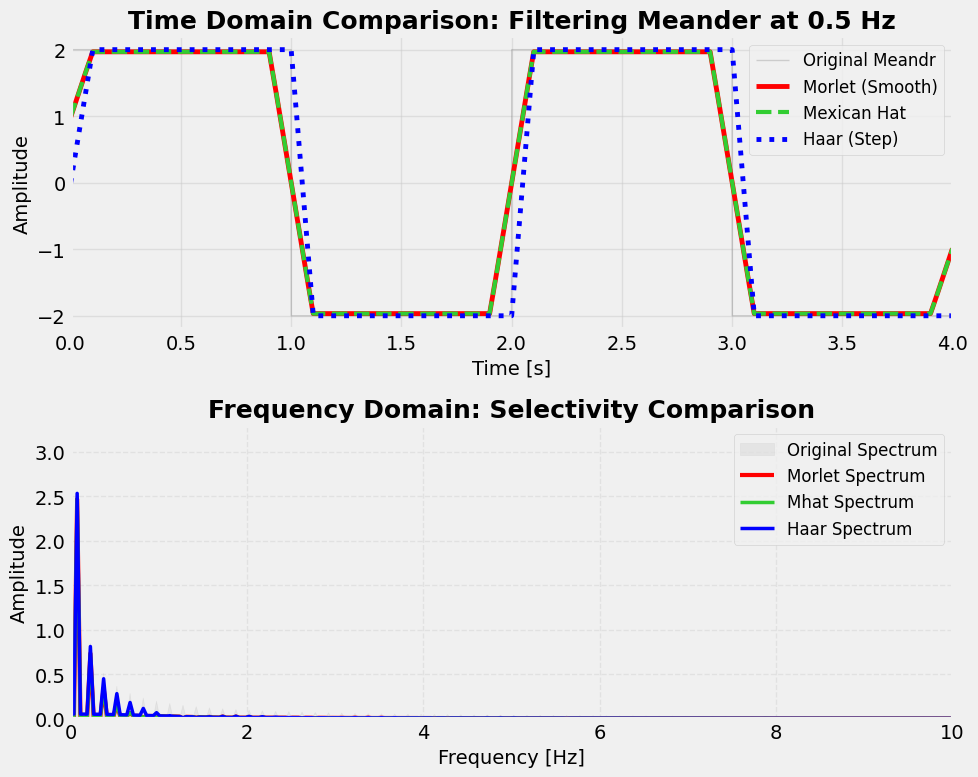

In [41]:
target_f = f_2 
target_w0 = 2 * np.pi * target_f
target_a = 1.0 / target_f


wavelet_morlet = time_morle_wavelet(t_wavelet, alpha=np.sqrt(2.0), w_0=target_w0)
wavelet_mhat   = time_mexican_hat_wavelet(t_wavelet, sigma=1.0, w_0=target_w0)
wavelet_haar   = time_haar_wavelet(t_wavelet, a=target_a)

filt_morlet = np.convolve(meandr_vals, wavelet_morlet, mode='same') / np.sum(np.abs(wavelet_morlet))
filt_mhat   = np.convolve(meandr_vals, wavelet_mhat, mode='same') / np.sum(np.abs(wavelet_mhat))
filt_haar   = np.convolve(meandr_vals, wavelet_haar, mode='same') / np.sum(np.abs(wavelet_haar))

N = len(meandr_vals)
freq_axis = np.fft.fftfreq(N, dt_2)
half = N // 2
def get_fft(sig): return np.abs(np.fft.fft(np.real(sig))) * 2 / N

orig_spectrum = get_fft(meandr_vals)
spec_morlet, spec_mhat, spec_haar = get_fft(filt_morlet), get_fft(filt_mhat), get_fft(filt_haar)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(t_vals2, meandr_vals, color='black', alpha=0.15, linewidth=1, label='Original Meandr')
plt.plot(t_vals2, np.real(filt_morlet), color='red',       linestyle='-',  linewidth=3.5, label='Morlet (Smooth)')
plt.plot(t_vals2, np.real(filt_mhat),   color='limegreen', linestyle='--', linewidth=3.0, label='Mexican Hat')
plt.plot(t_vals2, np.real(filt_haar),   color='blue',      linestyle=':',  linewidth=3.5, label='Haar (Step)')

plt.title(f'Time Domain Comparison: Filtering Meander at {target_f} Hz', fontsize=18, fontweight='bold')
plt.xlabel('Time [s]', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.xlim(0, duration)
plt.legend(loc='upper right', fontsize=12, frameon=True)
plt.grid(True, which='major', linestyle='-', alpha=0.5)

plt.subplot(2, 1, 2)
plt.fill_between(freq_axis[:half], orig_spectrum[:half], color='gray', alpha=0.1, label='Original Spectrum')

plt.plot(freq_axis[:half], spec_morlet[:half], color='red',       linewidth=3.0, label='Morlet Spectrum')
plt.plot(freq_axis[:half], spec_mhat[:half],   color='limegreen', linewidth=2.5, label='Mhat Spectrum')
plt.plot(freq_axis[:half], spec_haar[:half],   color='blue',      linewidth=2.5, label='Haar Spectrum')

plt.title('Frequency Domain: Selectivity Comparison', fontsize=18, fontweight='bold')
plt.xlabel('Frequency [Hz]', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.xlim(0, 10) 

plt.ylim(0, np.max([spec_morlet.max(), spec_mhat.max(), spec_haar.max()]) * 1.3)

plt.legend(loc='upper right', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [42]:
f_1 = 50.0
f_2 = 150.0
f_3 = 450.0

Fs = 2000 
dt_1 = 1.0 / Fs

w_1 = 2 * np.pi * f_1
w_2 = 2 * np.pi * f_2
w_3 = 2 * np.pi * f_3

signal_1 = lambda t : np.cos(w_1 * t) + np.cos(w_2 * t) + np.cos(w_3 * t)

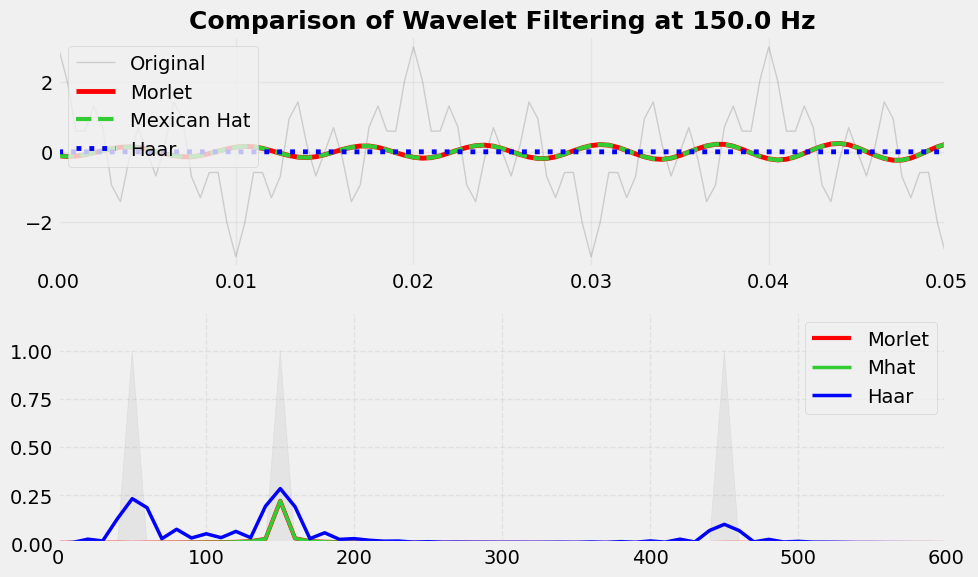

In [43]:
# 1. Используем уже существующий сигнал и время
t_vals = np.arange(0, 0.1, dt_1) 
signal_vals = signal_1(t_vals)

# Выбираем целевую частоту (возьмем f_2 = 150 Гц)
target_f = f_2 
target_w0 = 2 * np.pi * target_f
target_a = 1.0 / target_f

# 2. Генерация вейвлетов (используем твои функции)
wavelet_morlet = time_morle_wavelet(t_wavelet, alpha=np.sqrt(2.0), w_0=target_w0)
wavelet_mhat   = time_mexican_hat_wavelet(t_wavelet, sigma=1.0, w_0=target_w0)
wavelet_haar   = time_haar_wavelet(t_wavelet, a=target_a)

# 3. Фильтрация
filt_morlet = np.convolve(signal_vals, wavelet_morlet, mode='same') / np.sum(np.abs(wavelet_morlet))
filt_mhat   = np.convolve(signal_vals, wavelet_mhat, mode='same') / np.sum(np.abs(wavelet_mhat))
filt_haar   = np.convolve(signal_vals, wavelet_haar, mode='same') / np.sum(np.abs(wavelet_haar))

# 4. Синхронизация (защита от ValueError)
min_len = min(len(t_vals), len(filt_morlet), len(filt_mhat), len(filt_haar))
t_plot = t_vals[:min_len]
f_morlet, f_mhat, f_haar = np.real(filt_morlet)[:min_len], np.real(filt_mhat)[:min_len], np.real(filt_haar)[:min_len]

# 5. Спектры
def get_fft(sig): 
    return np.abs(np.fft.fft(sig)) * 2 / len(sig)

# --- ГРАФИК ---
plt.figure(figsize=(10, 6))

# Временная область
plt.subplot(2, 1, 1)
plt.plot(t_plot, signal_vals[:min_len], color='black', alpha=0.15, linewidth=1, label='Original')
plt.plot(t_plot, f_morlet, color='red',       linewidth=3.5, label='Morlet')
plt.plot(t_plot, f_mhat,   color='limegreen', linewidth=3.0, label='Mexican Hat', linestyle='--')
plt.plot(t_plot, f_haar,   color='blue',      linewidth=3.5, label='Haar', linestyle=':')
plt.title(f'Comparison of Wavelet Filtering at {target_f} Hz', fontsize=18, fontweight='bold')
plt.xlim(0, 0.05)
plt.legend()
plt.grid(True, alpha=0.3)

# Частотная область
plt.subplot(2, 1, 2)
freq_axis = np.fft.fftfreq(min_len, dt_1)
half = min_len // 2

plt.fill_between(freq_axis[:half], get_fft(signal_vals[:min_len])[:half], color='gray', alpha=0.1)
plt.plot(freq_axis[:half], get_fft(f_morlet)[:half], color='red',       linewidth=3.0, label='Morlet')
plt.plot(freq_axis[:half], get_fft(f_mhat)[:half],   color='limegreen', linewidth=2.5, label='Mhat')
plt.plot(freq_axis[:half], get_fft(f_haar)[:half],   color='blue',      linewidth=2.5, label='Haar')

plt.xlim(0, 600)
plt.ylim(0, 1.2)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Task5

- На рис 5.(а) приведен сигнал, частота которого меняется со временем. 
- На рис 5.(б) представлена спектрограмма данного сигнала, которая получена в результате свертки сигнала с вейвлетом Морле. 

Реализовать данный код на языке программирования Python. Разобраться в построении спектрограммы.

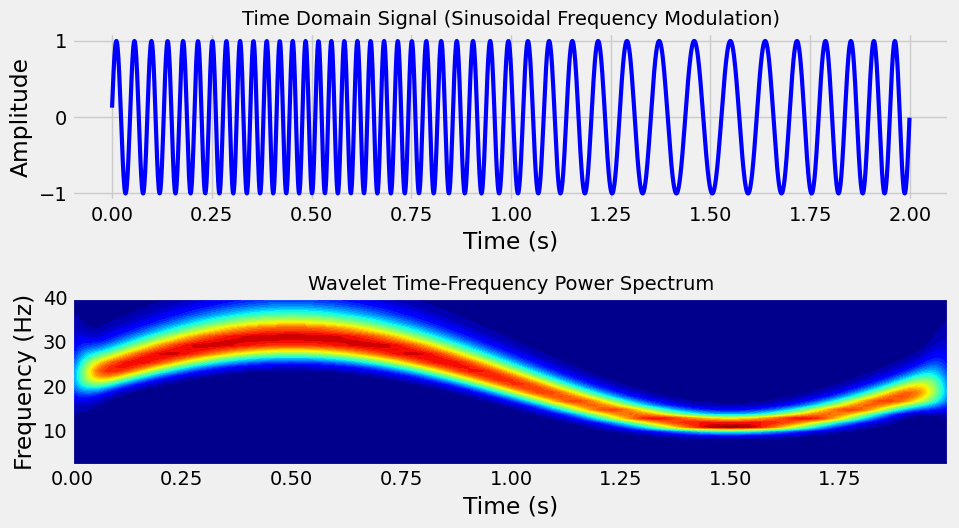

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft

srate = 1000  
t = np.arange(0, 2, 1/srate) 
n = len(t)


freq_base = 20  # Средняя частота
freq_amp = 10   # Отклонение частоты
# freqmod — это мгновенная частота в каждый момент времени
freqmod = freq_base + freq_amp * np.sin(2 * np.pi * 0.5 * t) 

# Важно: для фазы используем кумулятивную сумму частоты
signal = np.sin(2 * np.pi * (t + np.cumsum(freqmod)/srate))

num_frex = 40 
frex = np.linspace(2, 40, num_frex)
w_time = np.arange(-0.5, 0.5, 1/srate)
half_wave = len(w_time) // 2

tf = np.zeros((num_frex, n))
n_conv = len(w_time) + len(t) - 1  

sigX = fft(signal, n_conv)

for fi in range(num_frex):
    s = 6 / (2 * np.pi * frex[fi])  
    gaussian = np.exp(-w_time**2 / (2 * s**2))
    wavelet = np.exp(1j * 2 * np.pi * frex[fi] * w_time) * gaussian
    
    waveX = fft(wavelet, n_conv)
    waveX = waveX / np.max(waveX) 
    conv_res = ifft(waveX * sigX)

    conv_res = conv_res[half_wave : half_wave + n]

    tf[fi, :] = np.abs(conv_res)**2

plt.figure(figsize=(10, 5.5))

plt.subplot(211)
plt.plot(t, signal, color='b', linewidth=3)
plt.title('Time Domain Signal (Sinusoidal Frequency Modulation)', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(212)
plt.contourf(t, frex, tf, 40, cmap='jet')
plt.title('Wavelet Time-Frequency Power Spectrum', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()

## Task6

- Скачайте с интернета любой аудио файл, постройте для него три спектрограммы используя вейвлет Морле, вейвлет Хаара и вейвлет "Мексиканская шляпа". Объясните результаты.
- Убедитесь, что Ваш алгоритм работает правильно, для этого скачайте аудио звук любой чистой ноты и постройте для него три спектрограммы используя вейвлет Морле, вейвлет Хаара и вейвлет "Мексиканская шляпа". 

*Например, для ноты "ля" первой октавы основная гармоника должна соответствовать 440 Гц.*

In [45]:
from IPython.display import Audio

audio_file = 'images/blue_tractor.mp3' 

Audio(audio_file)

In [46]:
%%capture 
%pip install librosa

In [53]:
from pathlib import Path
import scipy.fftpack
from scipy.io import wavfile
from scipy.signal import resample_poly
from math import gcd

audio_params = {
    'audio_path': 'demo_audio.wav',
    'target_sr': 8000,
    'max_duration': 6.0,
    'freq_min': 80.0,
    'freq_max': 3000.0,
    'num_freqs': 64,
    'morlet_fwhm': 0.18,
    'mexican_sigma_factor': 0.25,
    'haar_scale_factor': 1.0,
}

def create_demo_audio(path, sr=8000, duration=6.0):
    time = np.arange(0, duration, 1 / sr)
    part1 = np.sin(2 * np.pi * (220 + 80 * np.sin(2 * np.pi * 0.8 * time)) * time)
    part2 = 0.6 * np.sin(2 * np.pi * 440 * time)
    part3 = 0.4 * np.sin(2 * np.pi * (660 + 220 * time / duration) * time)
    envelope = 0.6 + 0.4 * np.sin(2 * np.pi * 0.5 * time) ** 2
    demo = envelope * (part1 + part2 + part3)
    demo = demo / np.max(np.abs(demo))
    wavfile.write(path, sr, np.int16(demo * 32767))

def load_audio_file(path, target_sr=None, max_duration=None):
    path = Path(path)
    if not path.exists():
        create_demo_audio(path, sr=target_sr or 8000, duration=max_duration or 6.0)

    try:
        sr, audio = wavfile.read(path)
    except Exception:
        import soundfile as sf
        audio, sr = sf.read(path)

    audio = audio.astype(float)
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))

    if target_sr is not None and sr != target_sr:
        factor = gcd(int(sr), int(target_sr))
        up = int(target_sr // factor)
        down = int(sr // factor)
        audio = resample_poly(audio, up, down)
        sr = target_sr

    if max_duration is not None:
        audio = audio[:int(max_duration * sr)]

    time = np.arange(len(audio)) / sr
    return audio, sr, time, str(path)

def haar_wavelet_centered(t):
    psi = np.zeros_like(t, dtype=float)
    psi[(t >= -0.5) & (t < 0.0)] = 1.0
    psi[(t >= 0.0) & (t < 0.5)] = -1.0
    return psi

def compute_wavelet_spectrogram(signal, sr, frex, wavelet_type, morlet_fwhm=0.18, mexican_sigma_factor=0.25, haar_scale_factor=1.0):
    wavetime = np.arange(-1, 1, 1 / sr)
    nconv = len(signal) + len(wavetime) - 1
    half_wave = len(wavetime) // 2
    sigX = scipy.fftpack.fft(signal, nconv)
    tf = np.zeros((len(frex), len(signal)))

    for fi, freq in enumerate(frex):
        if wavelet_type == 'morlet':
            gaussian = np.exp(-4 * np.log(2) * wavetime ** 2 / morlet_fwhm ** 2)
            wavelet = np.exp(1j * 2 * np.pi * freq * wavetime) * gaussian
        elif wavelet_type == 'mexican_hat':
            sigma = max(0.002, mexican_sigma_factor / freq)
            x = wavetime
            wavelet = (1 - (x ** 2 / sigma ** 2)) * np.exp(-x ** 2 / (2 * sigma ** 2))
        elif wavelet_type == 'haar':
            scale = max(1 / sr, haar_scale_factor / freq)
            wavelet = haar_wavelet_centered(wavetime / scale) / np.sqrt(scale)
        else:
            raise ValueError('Unknown wavelet type')

        norm = np.sqrt(np.sum(np.abs(wavelet) ** 2))
        if norm > 0:
            wavelet = wavelet / norm

        waveX = scipy.fftpack.fft(wavelet, nconv)
        waveX = waveX / np.max(np.abs(waveX))
        convres = scipy.fftpack.ifft(waveX * sigX)
        convres = convres[half_wave:-half_wave + 1]
        tf[fi, :] = np.abs(convres) ** 2

    return tf

audio_signal, audio_sr, audio_time, loaded_path = load_audio_file(
    audio_params['audio_path'],
    target_sr=audio_params['target_sr'],
    max_duration=audio_params['max_duration'],
)

audio_freqs = np.geomspace(audio_params['freq_min'], min(audio_params['freq_max'], audio_sr / 2 * 0.95), audio_params['num_freqs'])

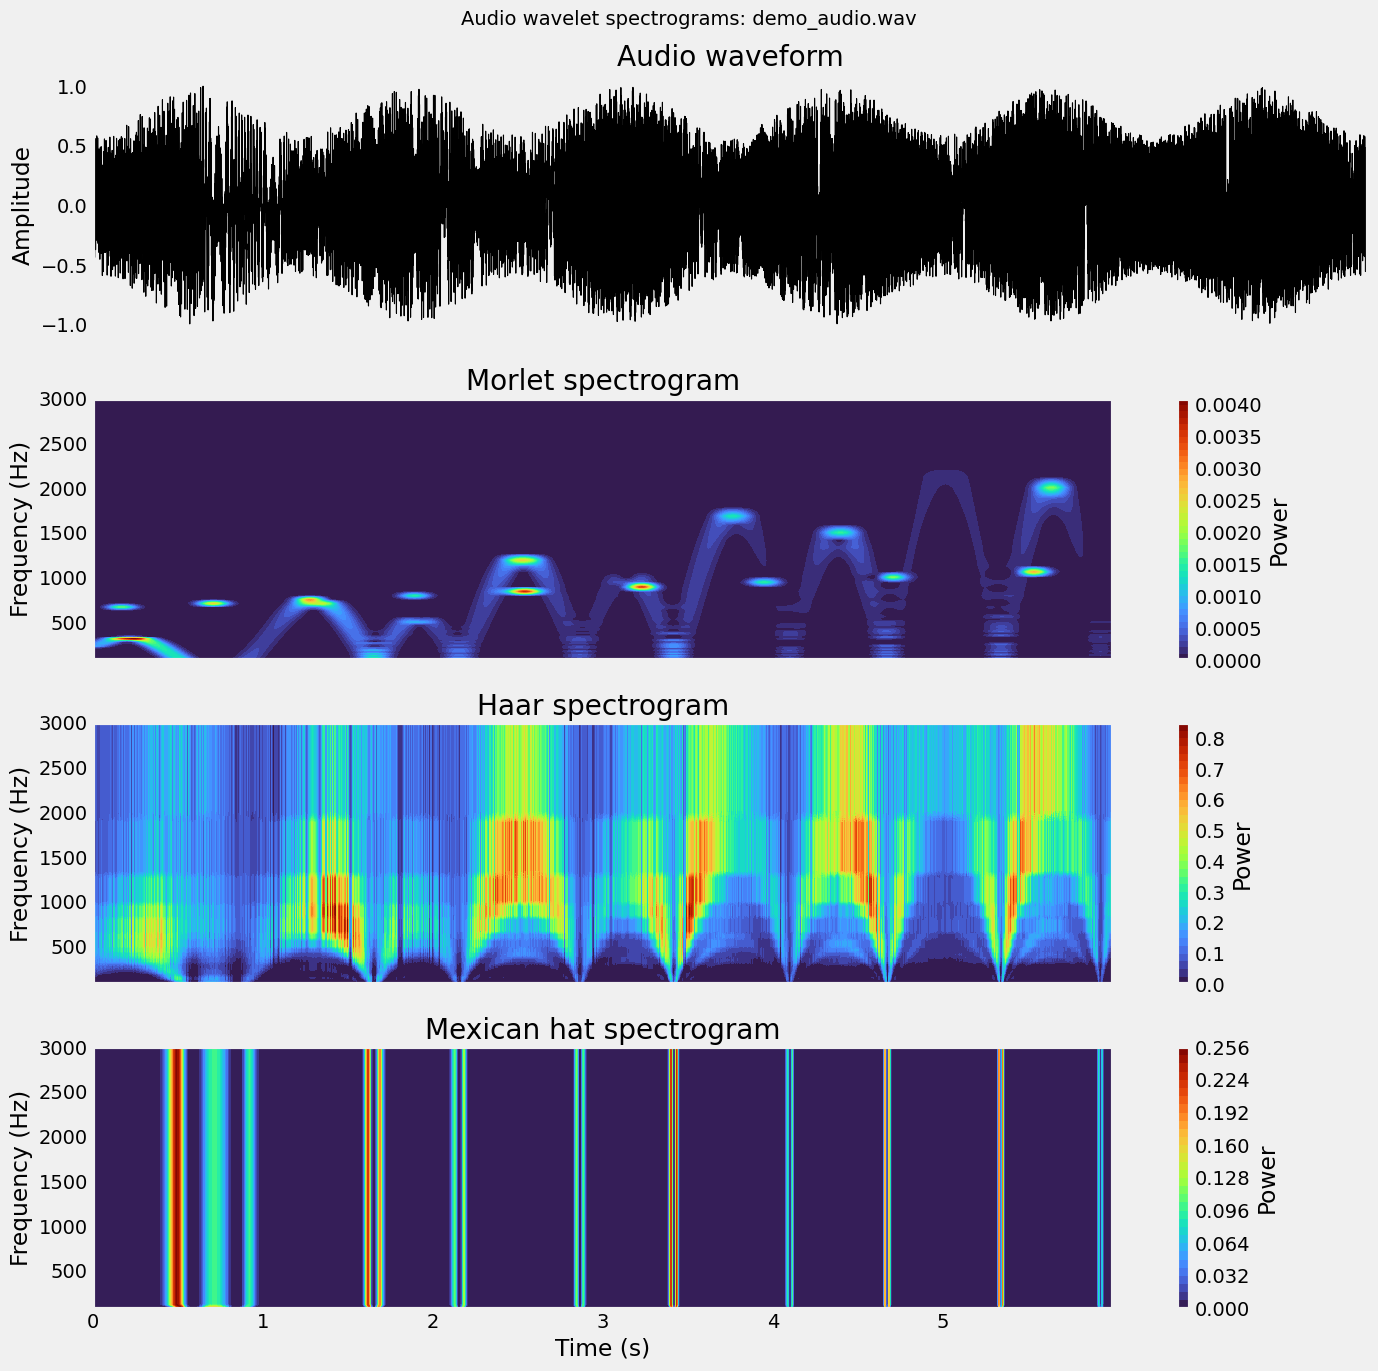

Loaded audio: demo_audio.wav
Sample rate: 8000 Hz, duration: 6.00 s, samples: 48000
To use your own file, change audio_params["audio_path"] to a local .wav/.mp3/.flac path and rerun the cell.


In [54]:
morlet_tf = compute_wavelet_spectrogram(
    audio_signal,
    audio_sr,
    audio_freqs,
    wavelet_type='morlet',
    morlet_fwhm=audio_params['morlet_fwhm'],
)
haar_tf = compute_wavelet_spectrogram(
    audio_signal,
    audio_sr,
    audio_freqs,
    wavelet_type='haar',
    haar_scale_factor=audio_params['haar_scale_factor'],
)
mexican_tf = compute_wavelet_spectrogram(
    audio_signal,
    audio_sr,
    audio_freqs,
    wavelet_type='mexican_hat',
    mexican_sigma_factor=audio_params['mexican_sigma_factor'],
)

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.suptitle(f'Audio wavelet spectrograms: {Path(loaded_path).name}', fontsize=14)

axes[0].plot(audio_time, audio_signal, color='black', lw=0.8)
axes[0].set_title('Audio waveform')
axes[0].set_ylabel('Amplitude')
axes[0].grid()

for ax, tf_map, title in [
    (axes[1], morlet_tf, 'Morlet spectrogram'),
    (axes[2], haar_tf, 'Haar spectrogram'),
    (axes[3], mexican_tf, 'Mexican hat spectrogram'),
]:
    contour = ax.contourf(audio_time, audio_freqs, tf_map, 40, cmap='turbo')
    fig.colorbar(contour, ax=ax, label='Power')
    ax.set_title(title)
    ax.set_ylabel('Frequency (Hz)')
    ax.grid(False)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

print(f'Loaded audio: {loaded_path}')
print(f'Sample rate: {audio_sr} Hz, duration: {audio_time[-1]:.2f} s, samples: {len(audio_signal)}')
print('To use your own file, change audio_params["audio_path"] to a local .wav/.mp3/.flac path and rerun the cell.')